## <u>Import Statements</u>

In [1]:
import os
#os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0" # hide warning messages by turning off oneDNN optimization

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import tensorflow as tf 
from tensorflow import keras
from datetime import datetime
import yfinance as yf
import mplfinance as mpf 
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import torch
from torch.utils.data import DataLoader, TensorDataset
from nbeats_pytorch.model import NBeatsNet

import warnings
warnings.filterwarnings("ignore")


## <u>Loading Financial Data</u>
- Leverage the yfinance library, Yahoo Finance's public API, to fetch historical market data.

In [2]:
# Create a ticker list grouped by sector to download market data
tickers = [
    # Technology
    "AAPL",   # Apple
    "MSFT",   # Microsoft
    "GOOGL",  # Alphabet
    "AMZN",   # Amazon
    "META",   # Meta
    "NVDA",   # Nvidia
    "AMD",    # AMD
    "ORCL",   # Oracle
    "CRM",    # Salesforce
    "INTC",   # Intel
    "IBM",    # IBM 

    # Finance
    "JPM",    # JPMorgan
    "BAC",    # Bank of America
    "GS",     # Goldman Sachs
    "MS",     # Morgan Stanley
    "V",      # Visa
    "MA",     # Mastercard
    "AXP",    # American Express
    "BLK",    # BlackRock

    # Healthcare
    "JNJ",    # Johnson & Johnson
    "PFE",    # Pfizer
    "MRK",    # Merck
    "UNH",    # UnitedHealth
    "ABBV",   # AbbVie
    "LLY",    # Eli Lilly

    # Energy
    "XOM",    # ExxonMobil
    "CVX",    # Chevron
    "COP",    # ConocoPhillips
    "SLB",    # Schlumberger

    # Consumer / Retail
    "WMT",    # Walmart
    "COST",   # Costco
    "TGT",    # Target
    "HD",     # Home Depot
    "MCD",    # McDonald's
    "SBUX",   # Starbucks
    "NKE",    # Nike
    "KO",     # Coca-Cola
    "PEP",    # PepsiCo

    # Industrials
    "CAT",    # Caterpillar
    "BA",     # Boeing
    "GE",     # General Electric
    "HON",    # Honeywell
    "UPS",    # UPS

    # Transportation / Automotive
    "TSLA",   # Tesla
    "F",      # Ford
    "GM",     # General Motors
    "DAL",    # Delta Airlines

    # Telecom / Media
    "DIS",    # Disney
    "NFLX",   # Netflix
    "T",      # AT&T
    "VZ",     # Verizon

    # ETFs / Market Benchmarks
    "SPY",    # S&P 500 ETF
    "QQQ",    # Nasdaq ETF
]

start_year = 2020
end_year = 2026
year_range = end_year - start_year

if end_year <= start_year:
    raise ValueError("End year must be greater than start year.")
if year_range < 3:
    raise ValueError("Please select at least 3 years of data for reliable model training.")
if year_range > 10:
    raise ValueError("Please select no more than 10 years of data to keep the analysis focused and efficient.")

data = yf.download(tickers, start = f"{start_year}-01-01", end = f"{end_year + 1}-01-01", group_by = "ticker")

data = data.stack(level = 0).reset_index()
data = data.rename(columns = {"level_0": "Date"})
data.columns.name = None

[*********************100%***********************]  53 of 53 completed


In [3]:
# Verify the dataset was correctly downloaded from yfinance
assert len(data[data["Ticker"] == "AAPL"]) == len(data[data["Ticker"] == "MSFT"]), "Count of data points for stocks do not match"

# Generate info regarding dataframe structure
print(data.shape)
print(data.sample(10))
data.info()

(86708, 7)
            Date Ticker        Open        High         Low       Close  \
17382 2021-04-21    WMT   43.849839   44.139535   43.775081   43.983784   
70671 2025-04-23    IBM  238.279380  241.514552  236.012824  237.775696   
61230 2024-08-06      F    8.650611    8.712463    8.553413    8.641774   
31062 2022-04-29    AXP  170.801700  172.907203  165.338782  165.699188   
33298 2022-06-30    DIS   91.546152   92.535110   89.723376   91.526764   
26991 2022-01-07    DIS  152.124452  154.451413  151.533018  153.026154   
3684  2020-04-13    LLY  135.109563  136.619371  133.161722  134.596970   
78435 2025-11-19    UPS   90.423489   91.170306   89.599071   89.628174   
70425 2025-04-15   SBUX   82.719381   83.261167   80.745725   80.987595   
58428 2024-05-20    IBM  159.942222  161.040054  159.355457  160.812912   

          Volume  
17382   17335200  
70671    7948300  
61230  111817600  
31062    3210100  
33298   10983500  
26991    9554600  
3684     2289000  
78435    56

## <u>Exploratory Data Analysis</u>
- Reviewed and visualized stock performance across three sectors: Information Technology, Financials, and Health Care
- Created candlestick charts to capture market data

In [4]:
# Candlestick chart visualization function
def plot_candlestick_with_volume(company: str, data: pd.DataFrame):
    c = data[data["Ticker"] == company].copy()
    c.set_index("Date", inplace = True)

    fig, axes = mpf.plot(c, type = "candle", style = "yahoo", ylabel = "Price (USD)", volume = True, figsize = (18, 9), returnfig = True, update_width_config = dict(candle_linewidth = 1, candle_width = 0.3))
    
    axes[0].set_title(f"{company}", fontsize = 20, fontweight = "bold", pad = 10)
    axes[0].set_ylabel("Price (USD)", fontsize = 12)
    axes[2].set_ylabel("Volume", fontsize = 12)
    axes[0].yaxis.set_label_position("left")
    axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1e}'))
    axes[0].yaxis.tick_left()

    dates = c.index
    six_month_periods = pd.date_range(start = f"{c.index[0].year}-01-01", end = c.index[-1], freq='6MS')
    
    tick_positions = [np.argmin(np.abs(dates - t)) for t in six_month_periods]
    tick_labels = [t.strftime('%b %Y') for t in six_month_periods]
    axes[0].set_xticks(tick_positions)
    axes[0].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    mpf.show()

---
#### **Information Technology Sector**
Selected the following companies for information technology stock visualizations: 

- AAPL — Apple Inc.
- MSFT — Microsoft Corporation
- GOOGL — Alphabet Inc.
- AMZN — Amazon.com, Inc.
- META — Meta Platforms, Inc.
- NVDA — NVIDIA Corporation
- AMD — Advanced Micro Devices, Inc.
- ORCL — Oracle Corporation
- CRM — Salesforce, Inc.
- INTC — Intel Corporation
- IBM — International Business Machines Corporation

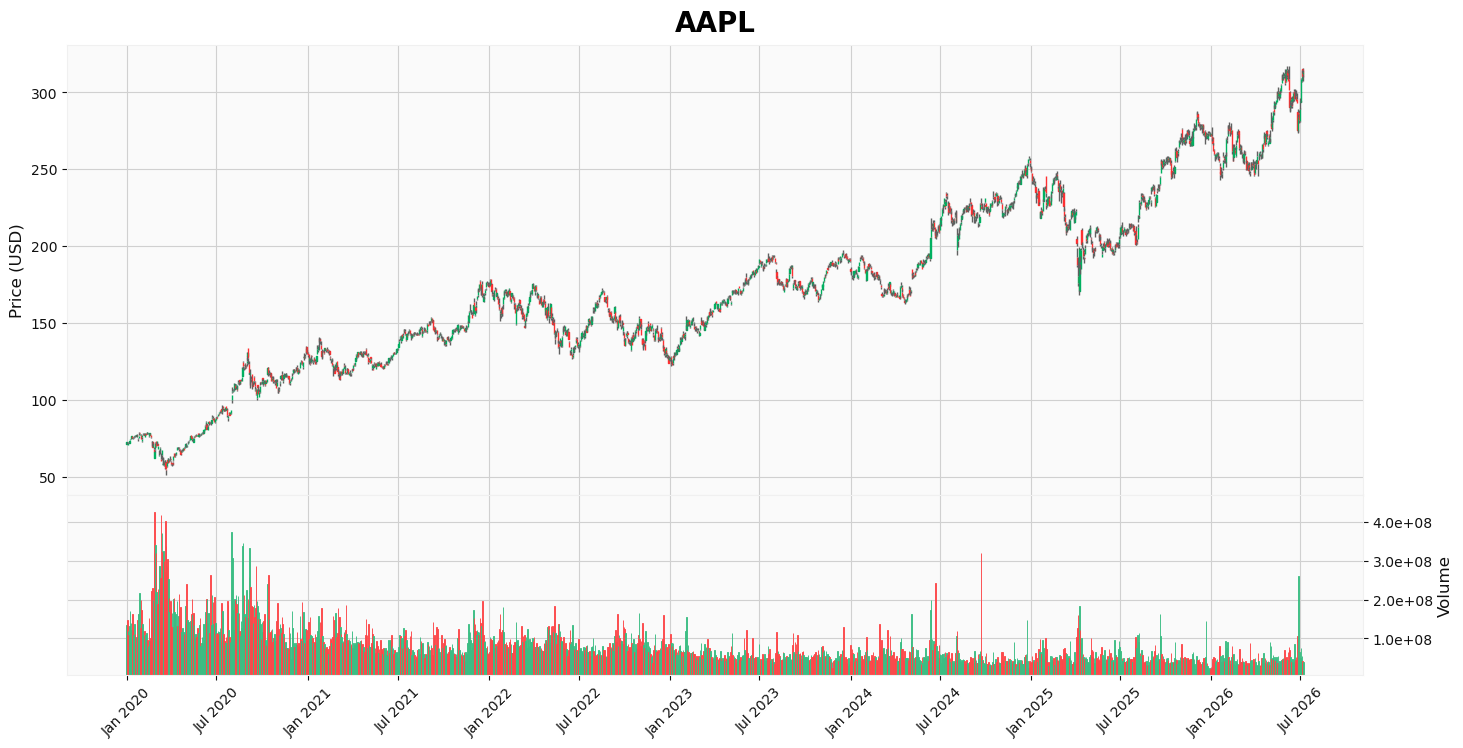

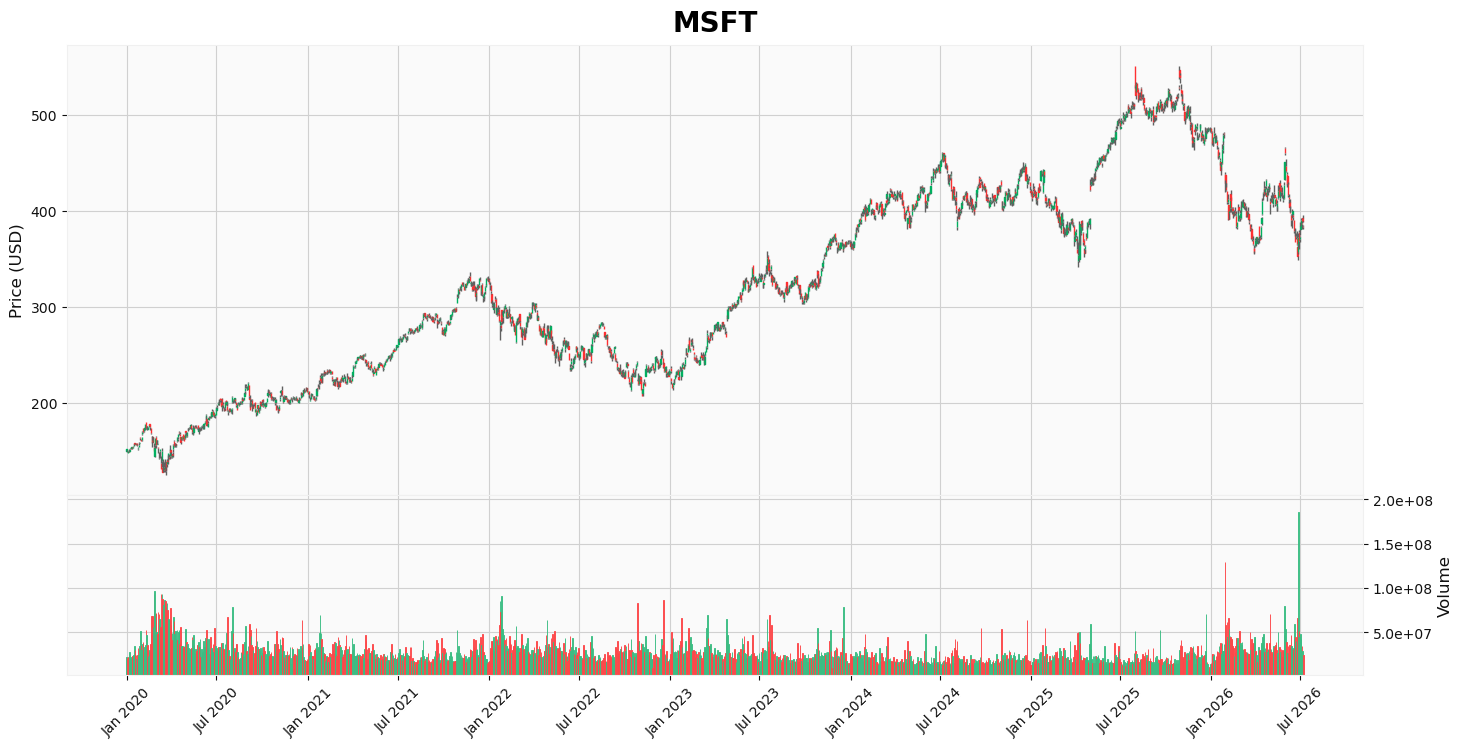

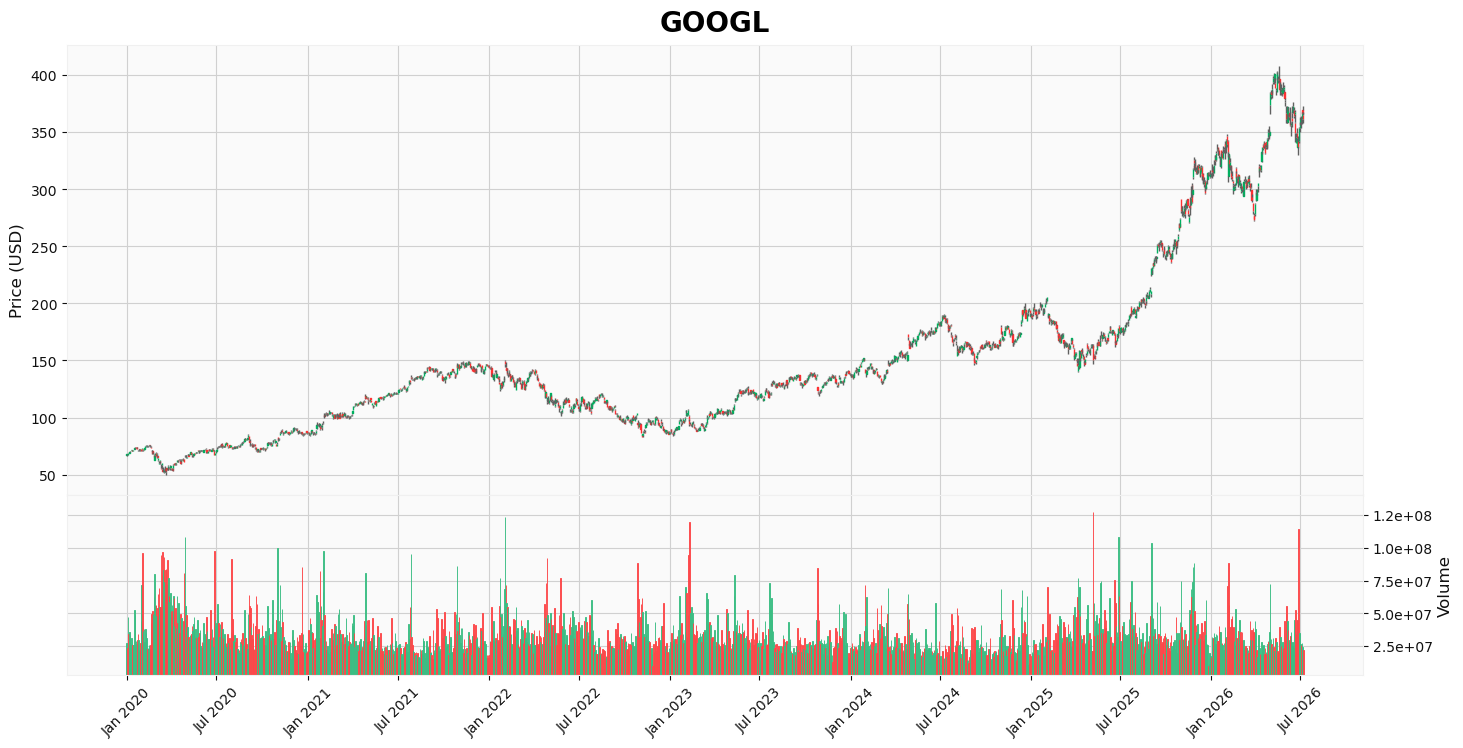

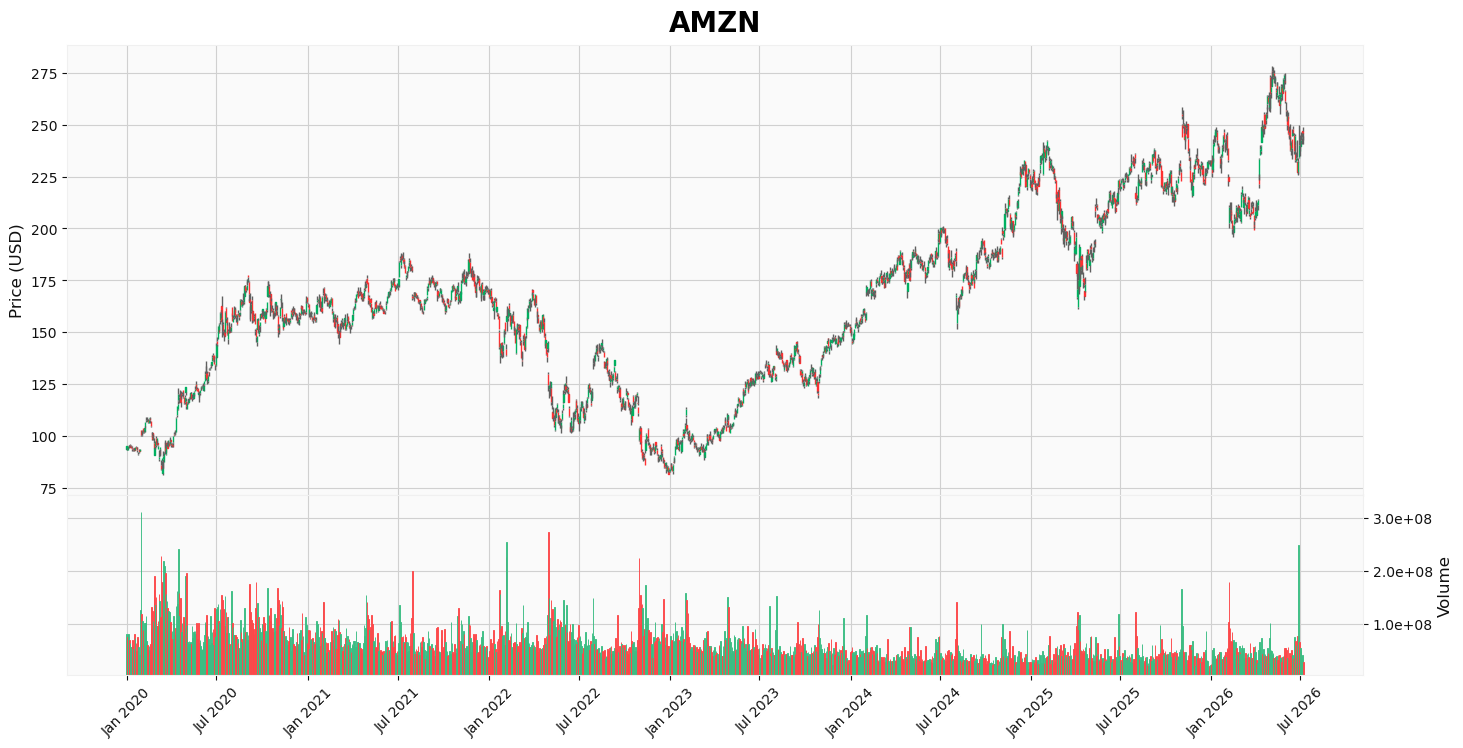

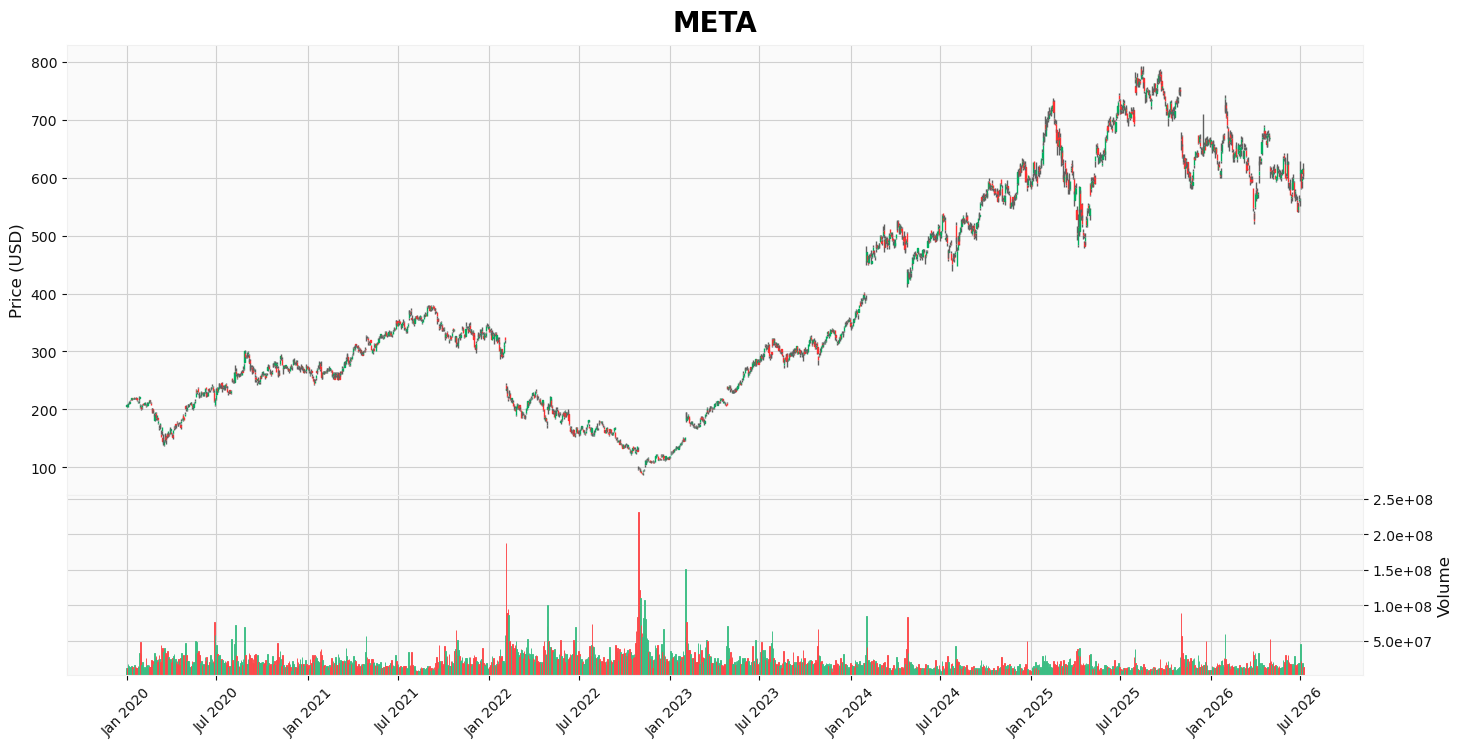

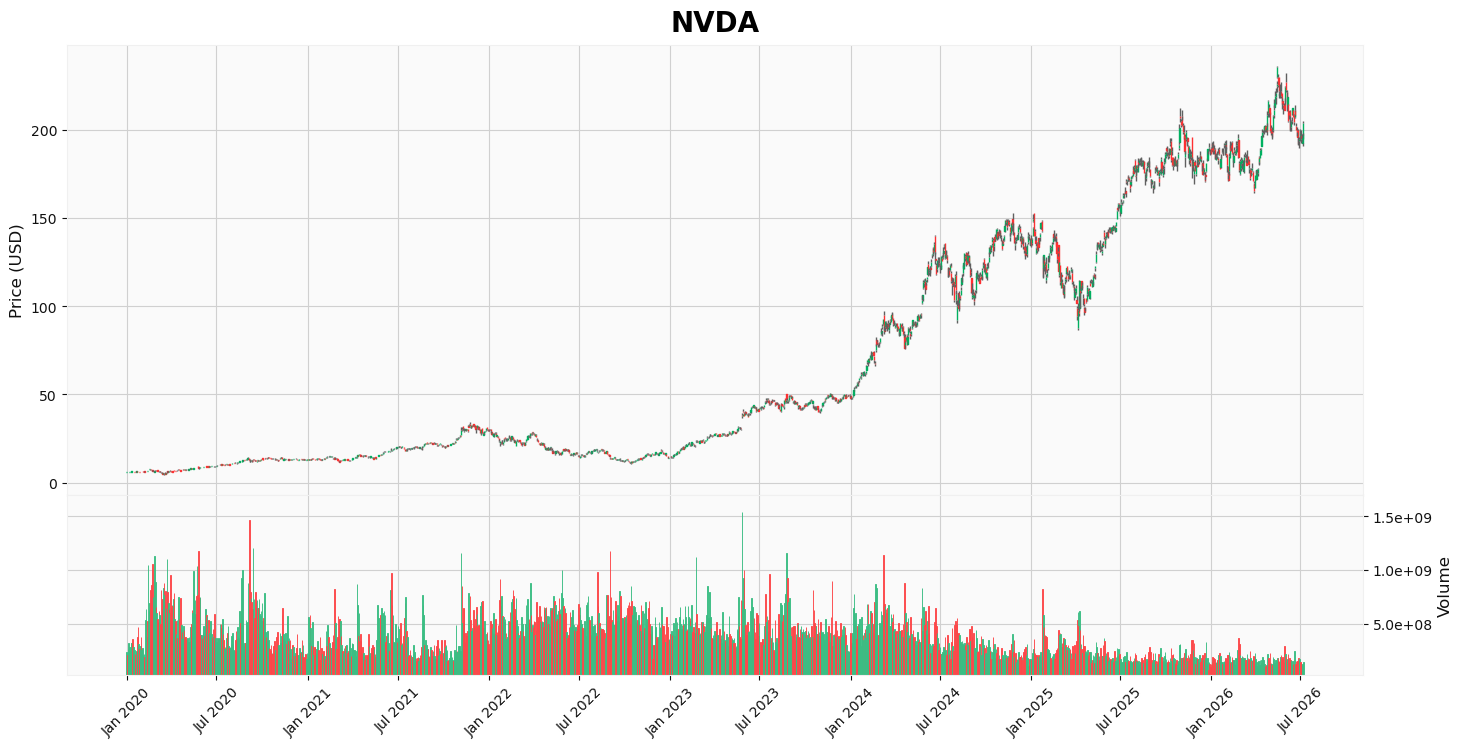

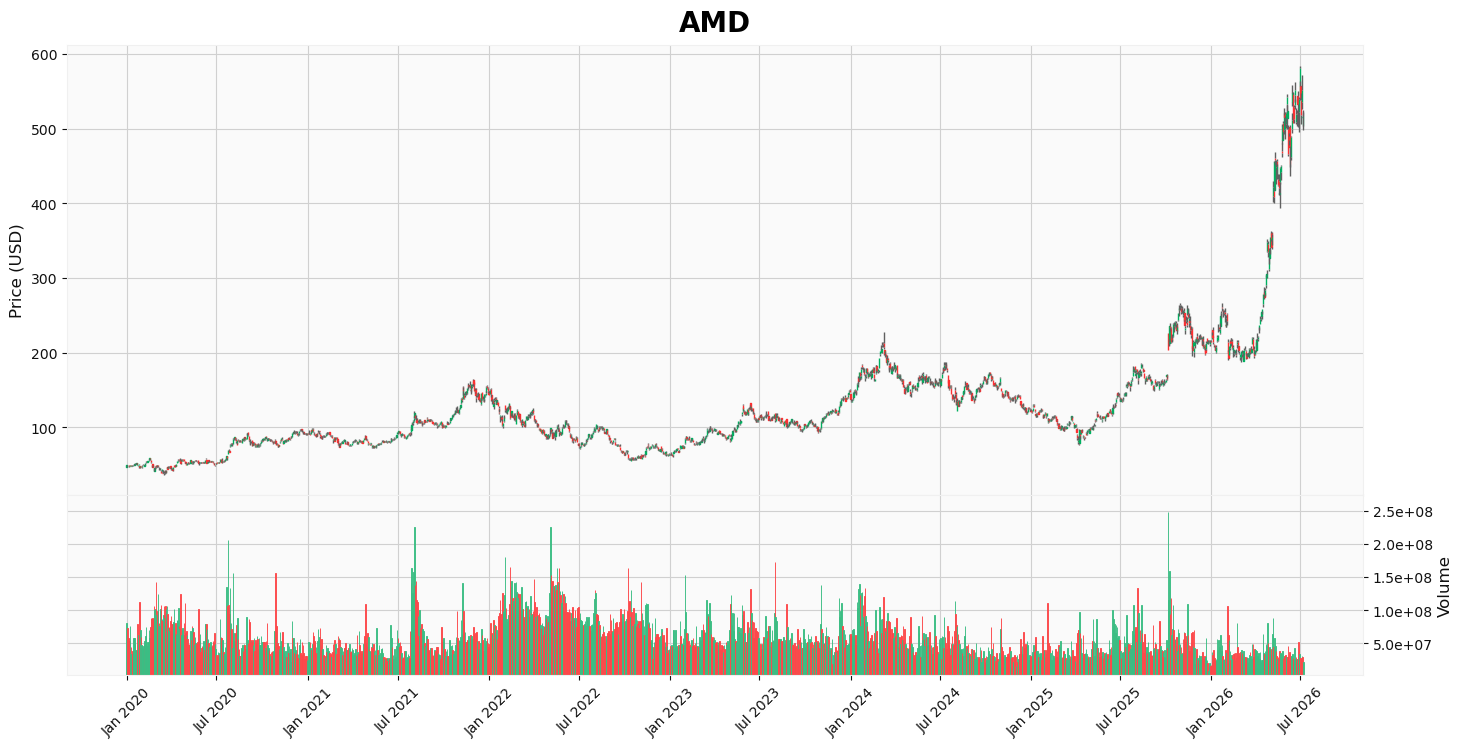

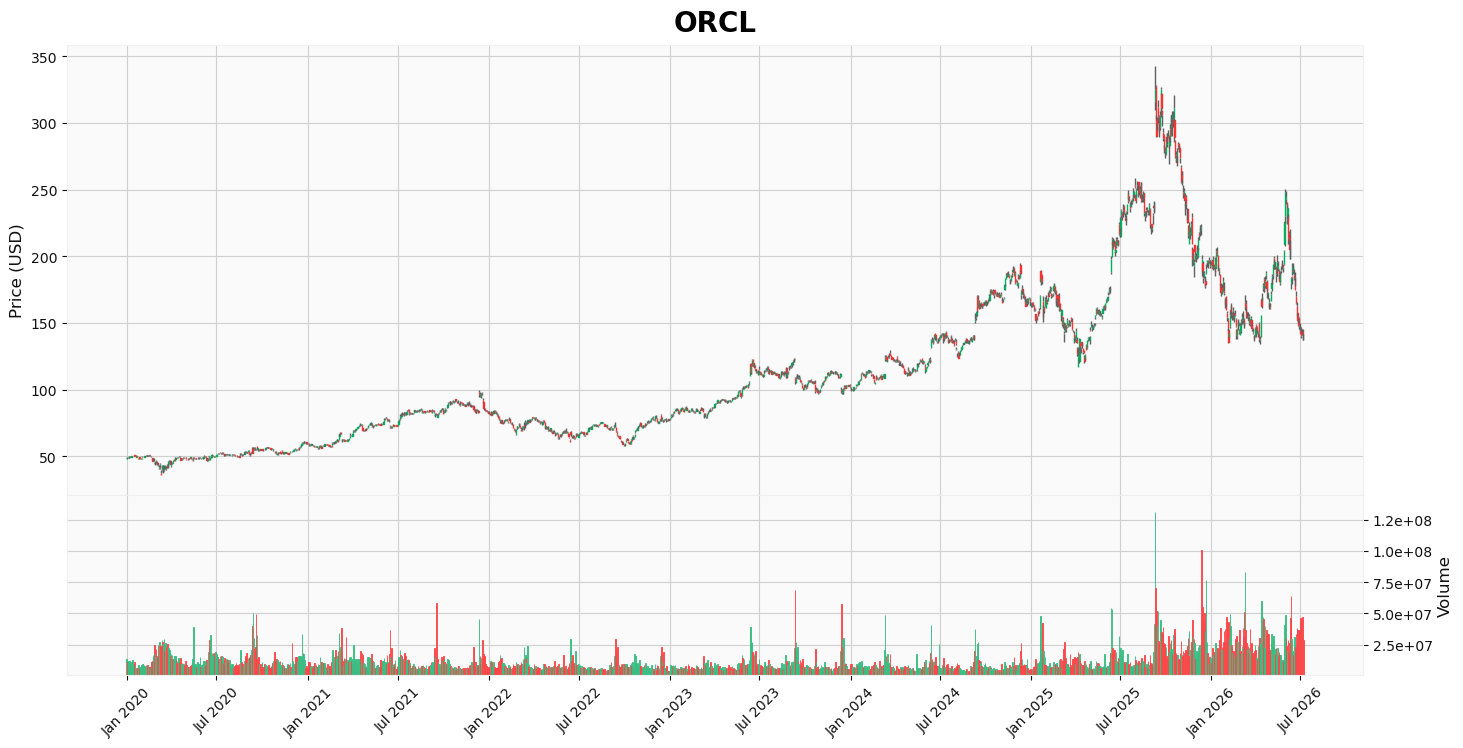

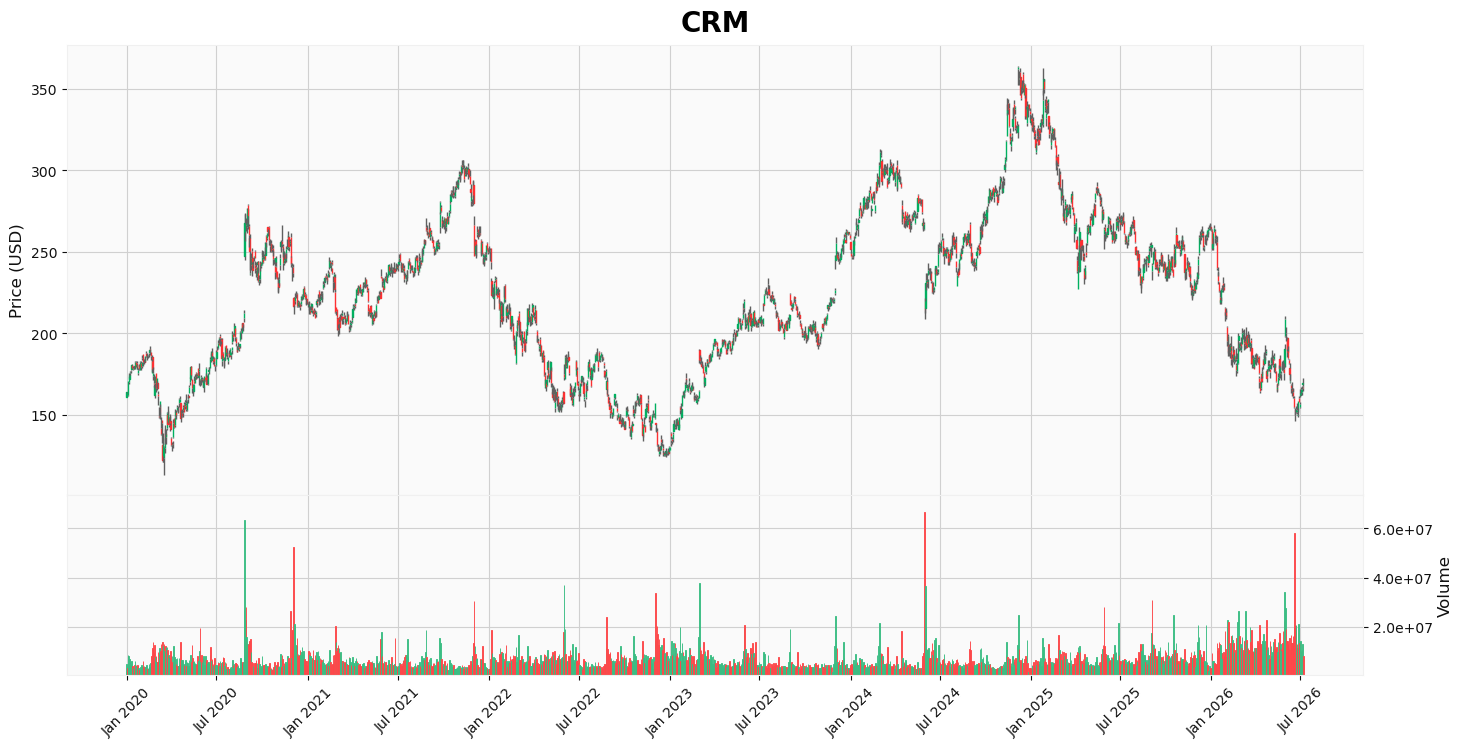

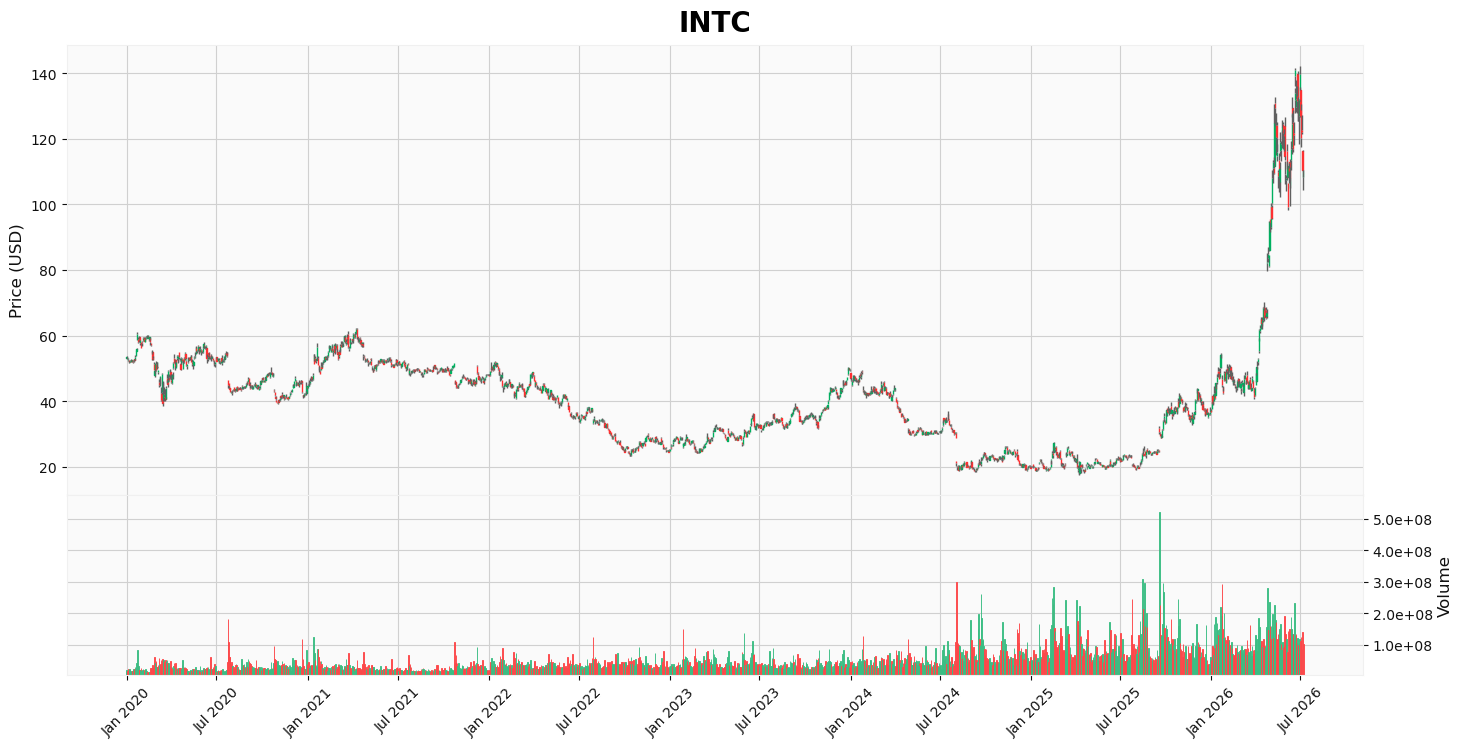

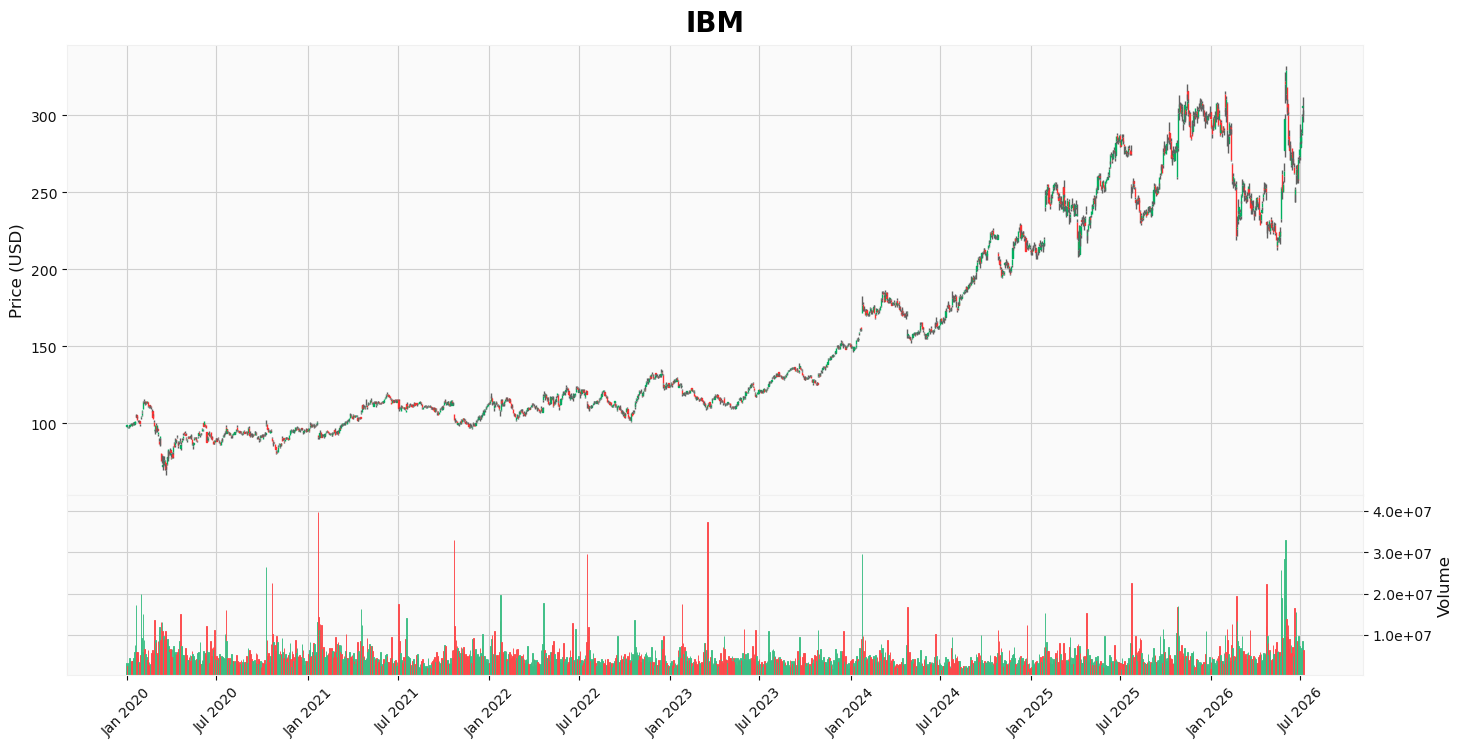

In [5]:
tech_companies = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "AMD", "ORCL", "CRM", "INTC", "IBM"] 

for comp in tech_companies:
    plot_candlestick_with_volume(comp, data)

---
#### **Financials Sector**
Selected the following companies for financial stock visualizations: 

- JPM — JPMorgan Chase & Co.
- BAC — Bank of America Corporation
- GS — The Goldman Sachs Group, Inc.
- MS — Morgan Stanley
- V — Visa Inc.
- MA — Mastercard Incorporated
- AXP — American Express Company
- BLK — BlackRock, Inc.

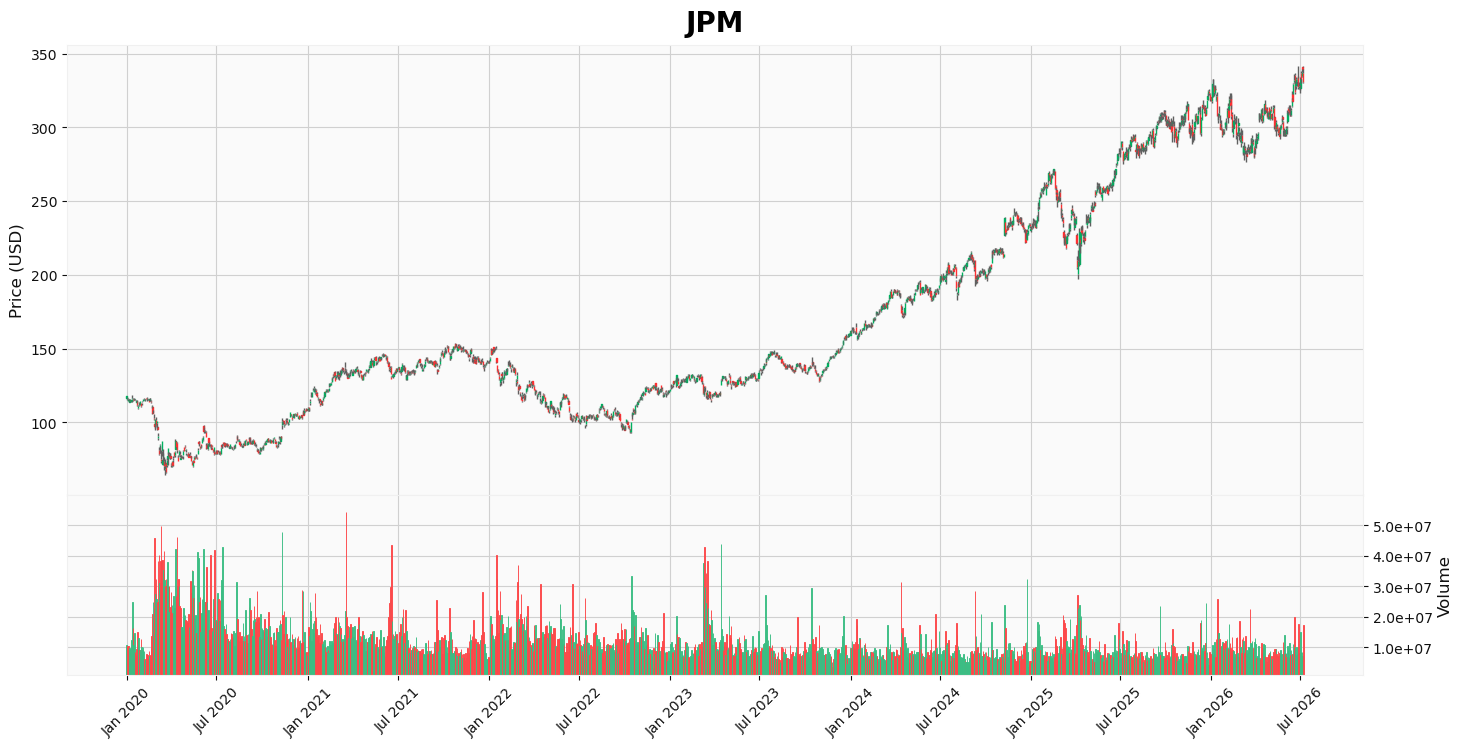

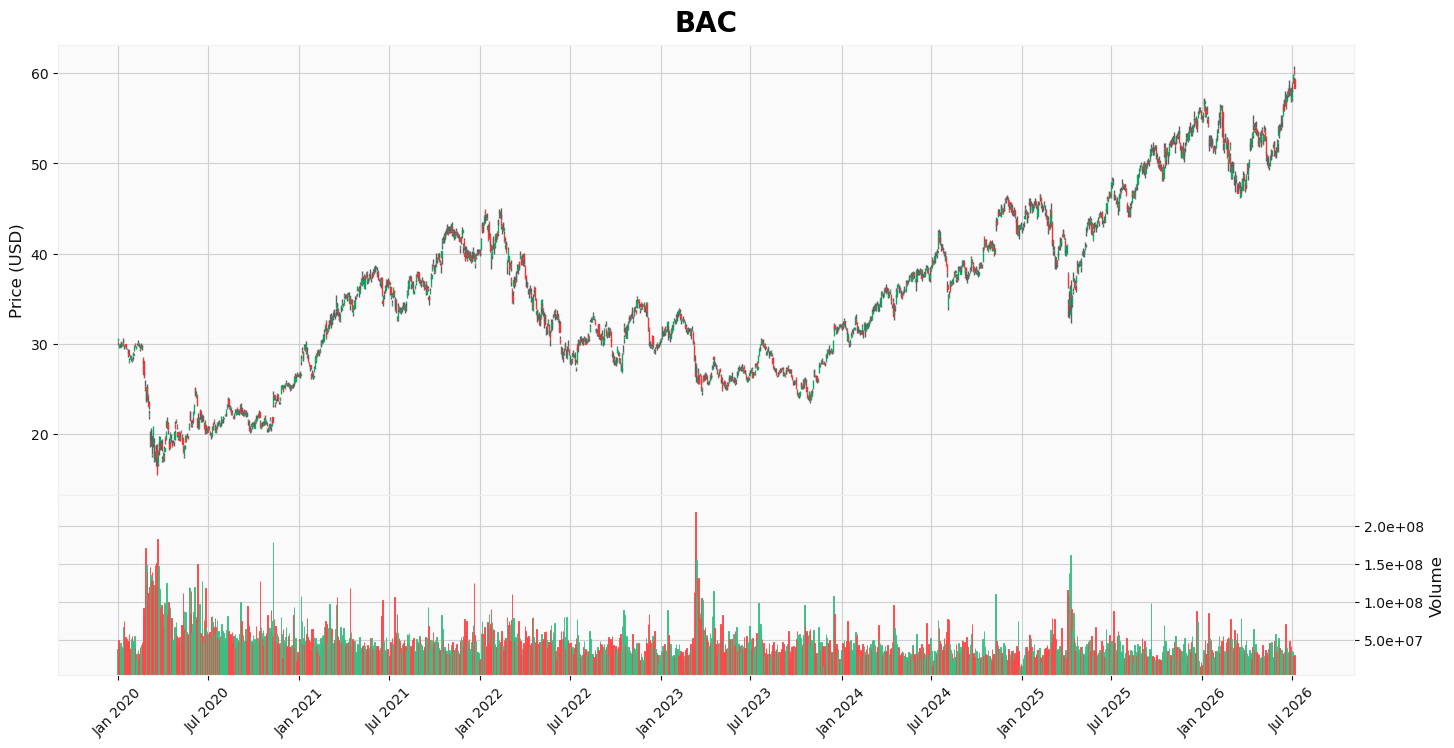

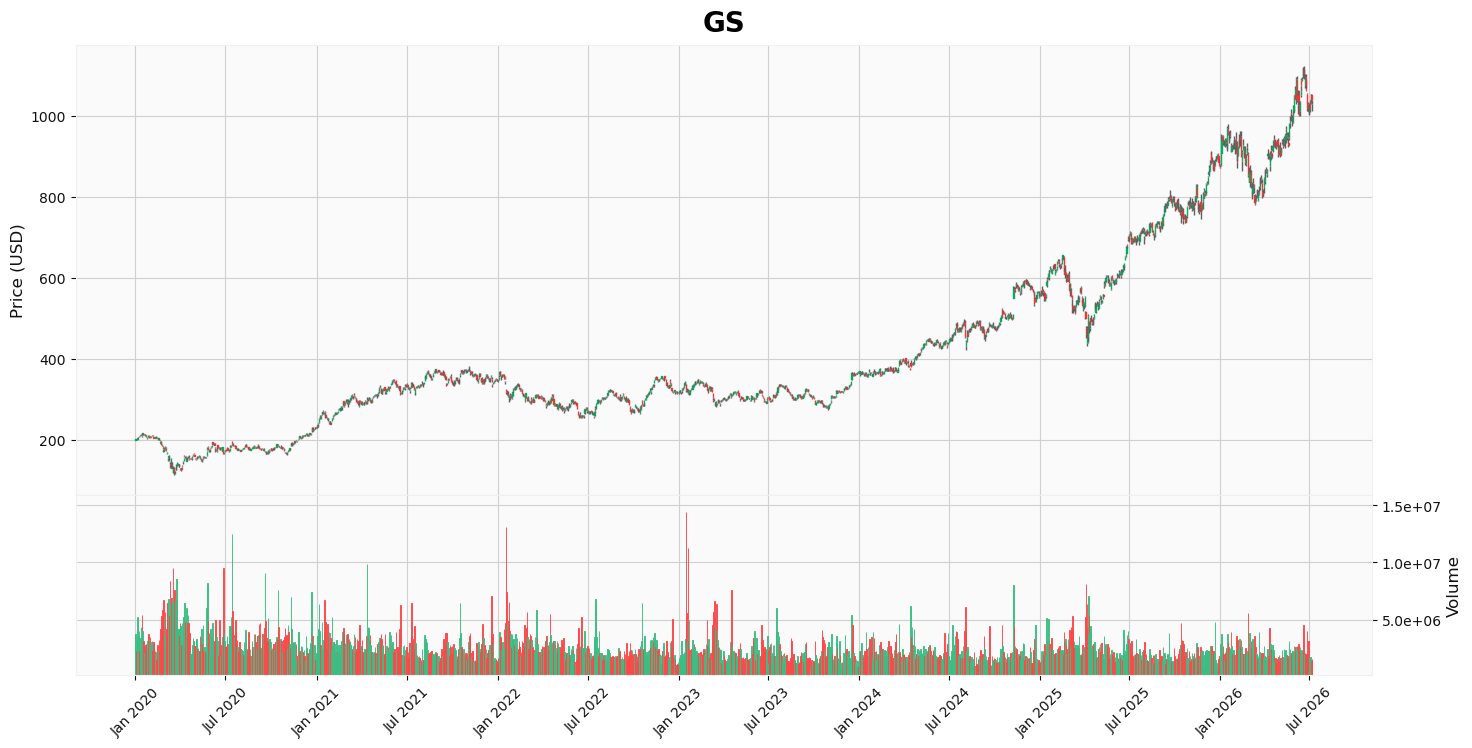

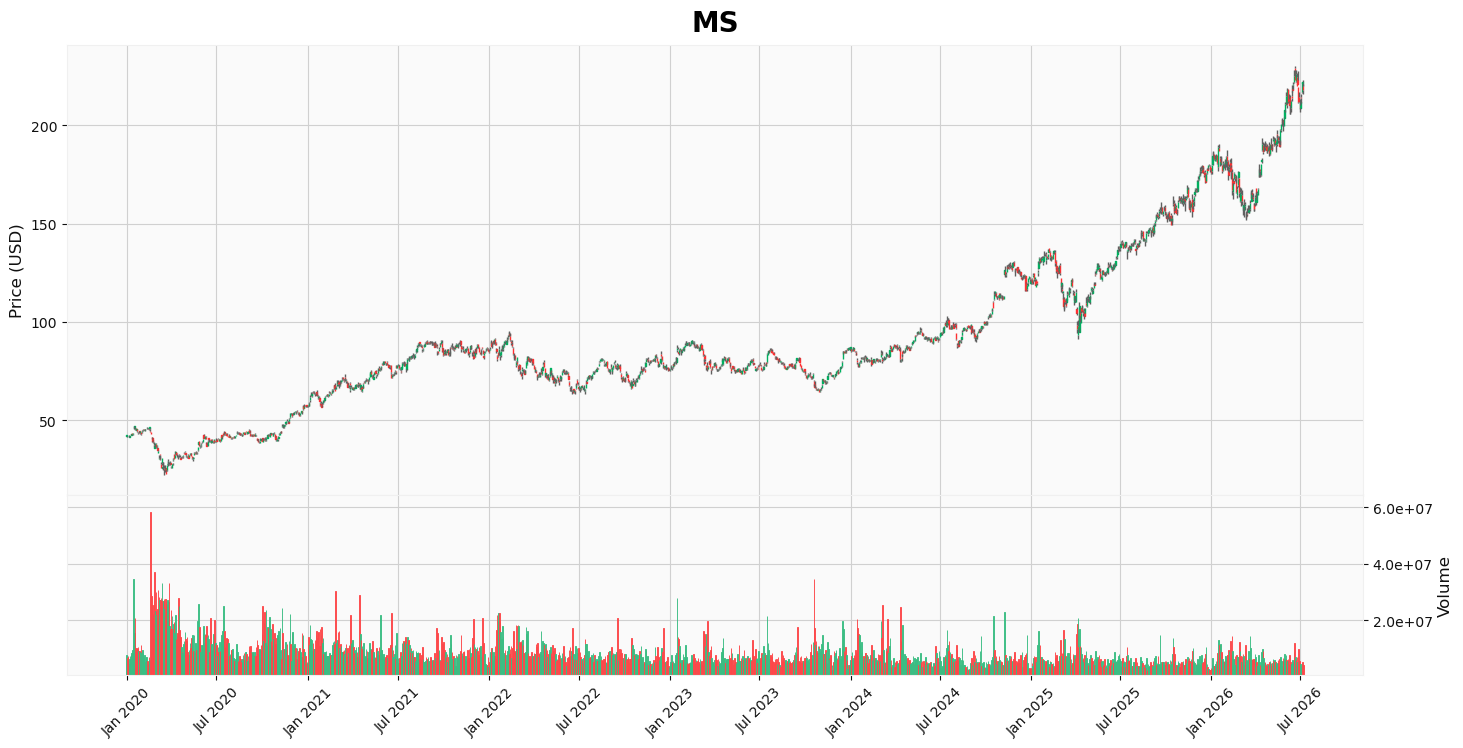

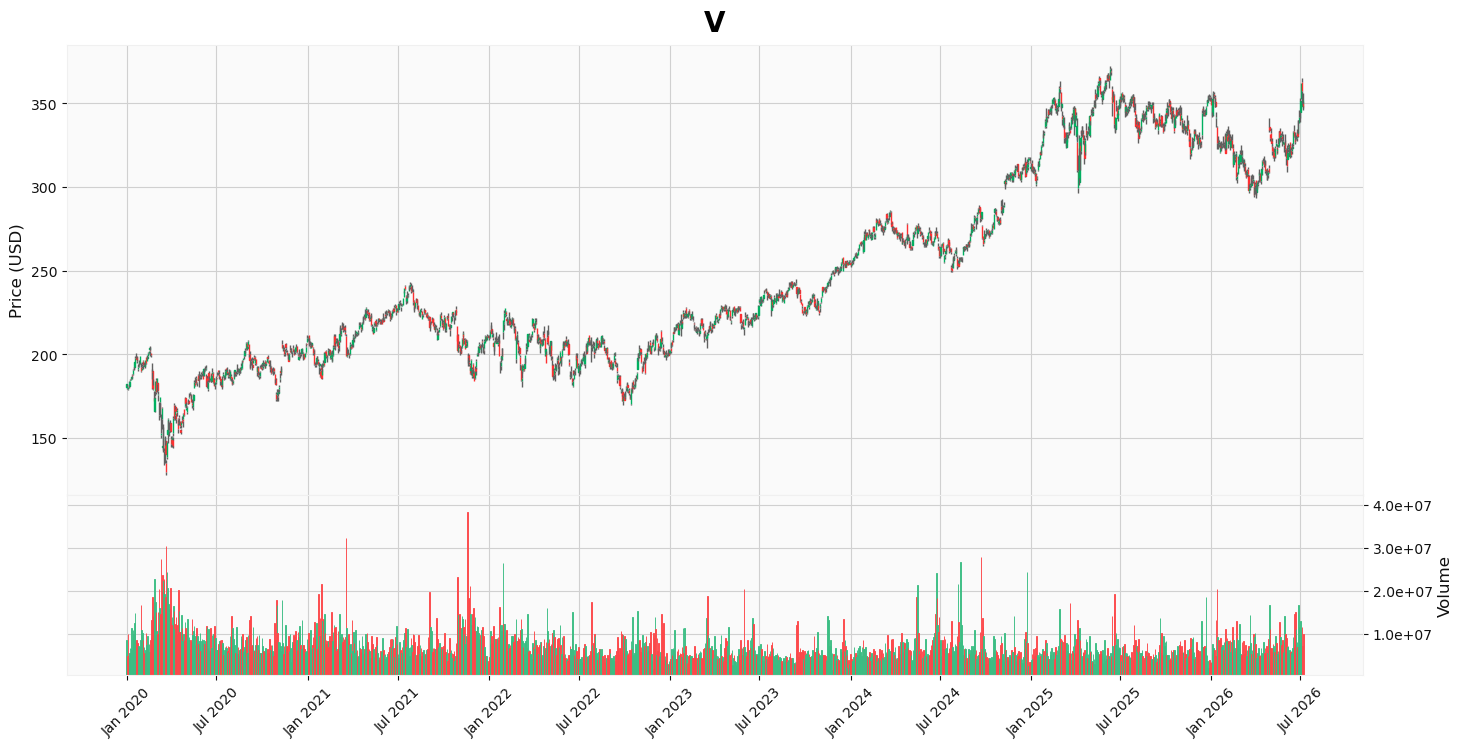

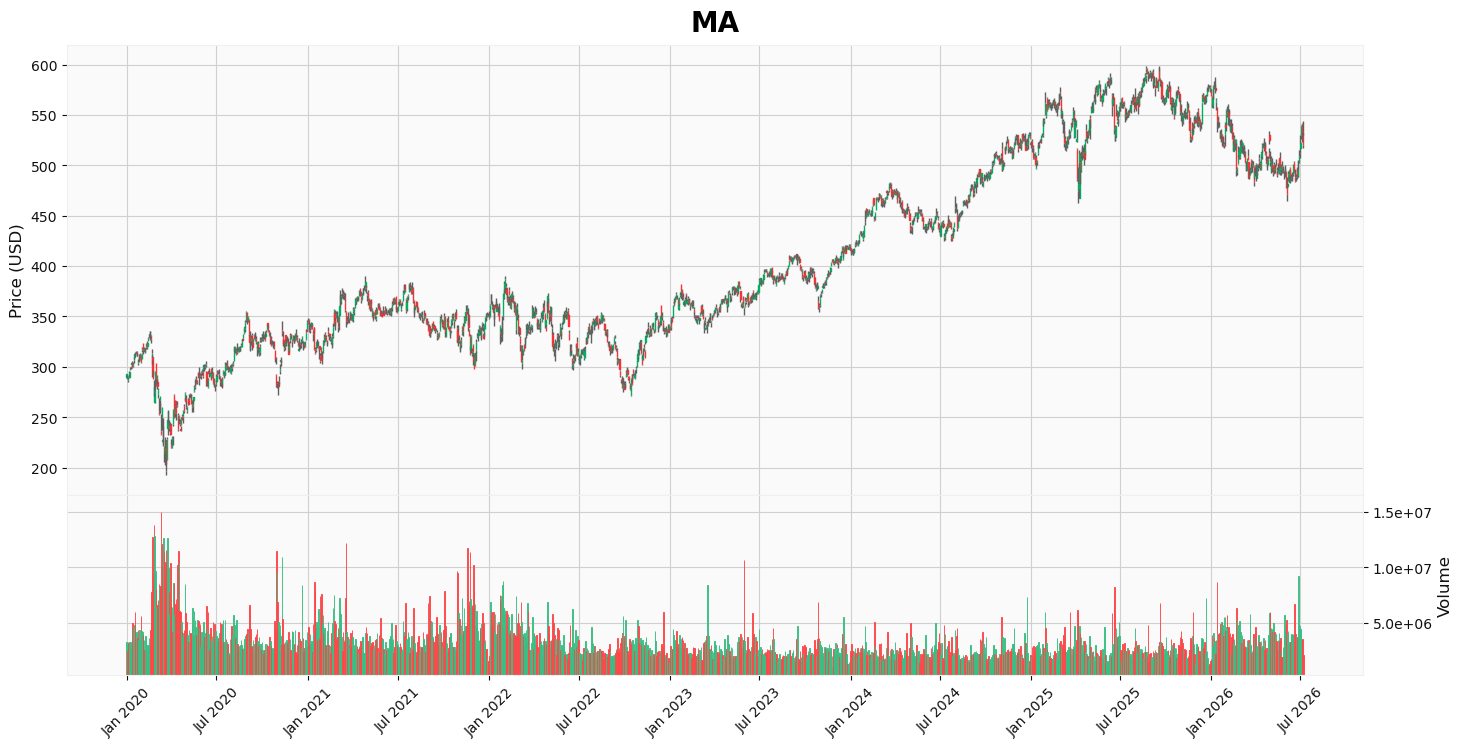

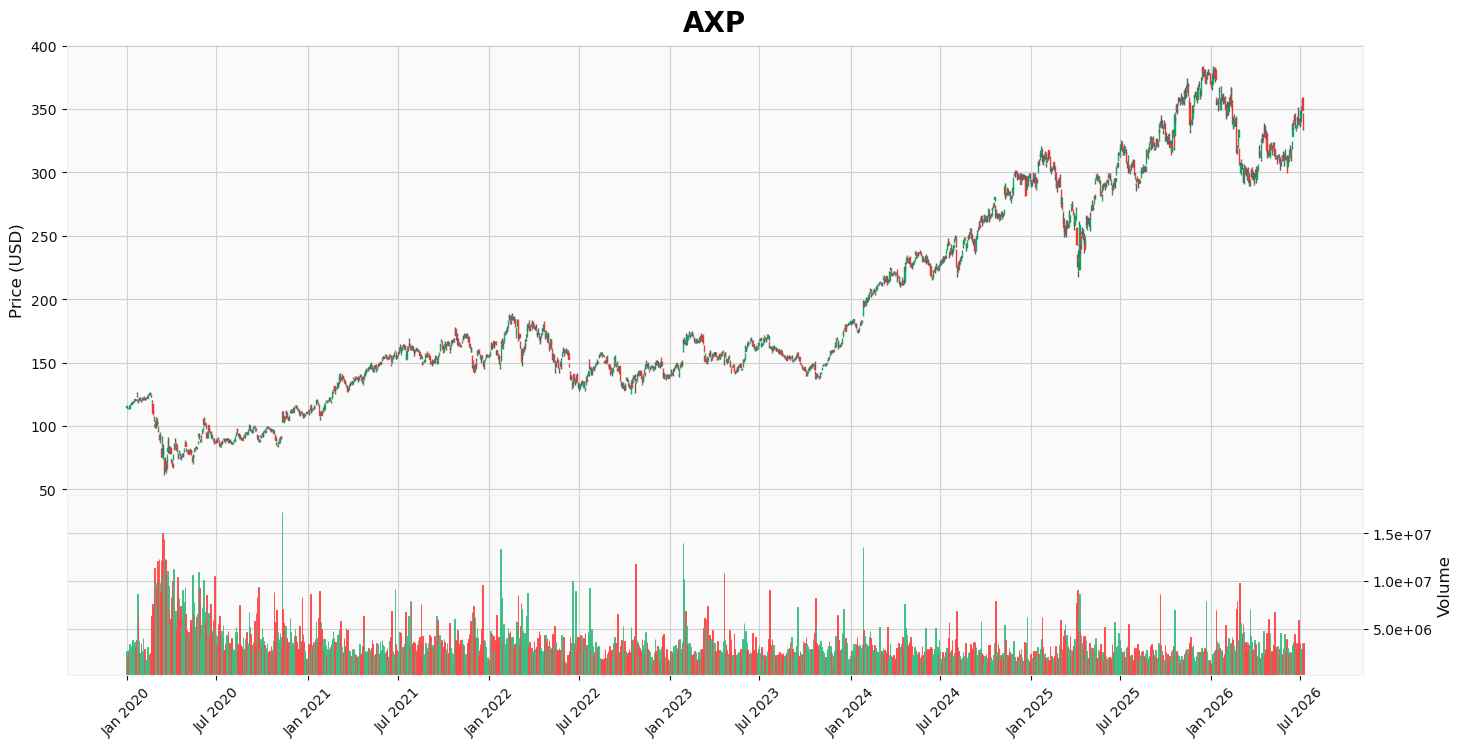

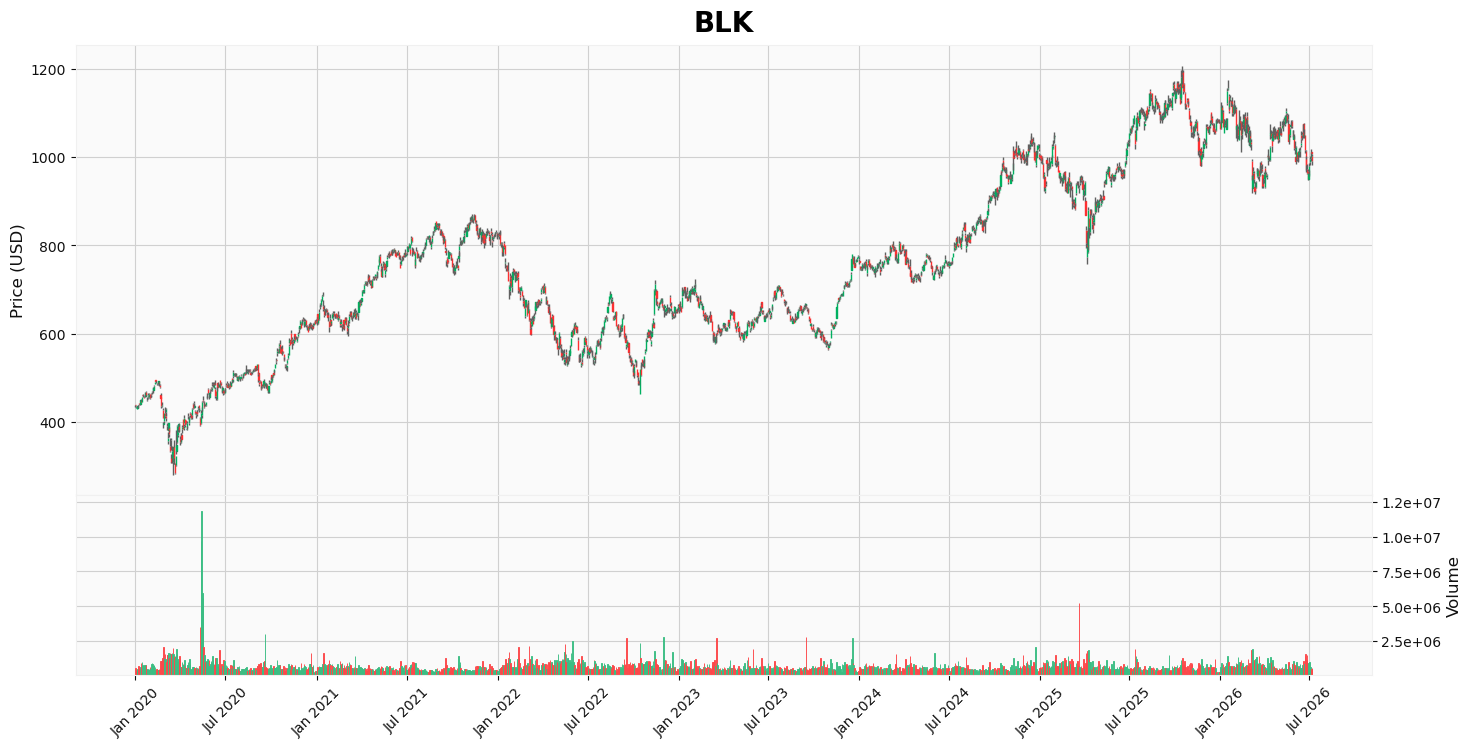

In [6]:
finance_companies = ["JPM", "BAC", "GS", "MS", "V", "MA", "AXP", "BLK"]

for comp in finance_companies:
    plot_candlestick_with_volume(comp, data)

---
#### **Health Care Sector**
Selected the following companies for health care stock visualizations: 

- JNJ — Johnson & Johnson
- PFE — Pfizer Inc.
- MRK — Merck & Co., Inc.
- UNH — UnitedHealth Group Incorporated
- ABBV — AbbVie Inc.
- LLY — Eli Lilly and Company

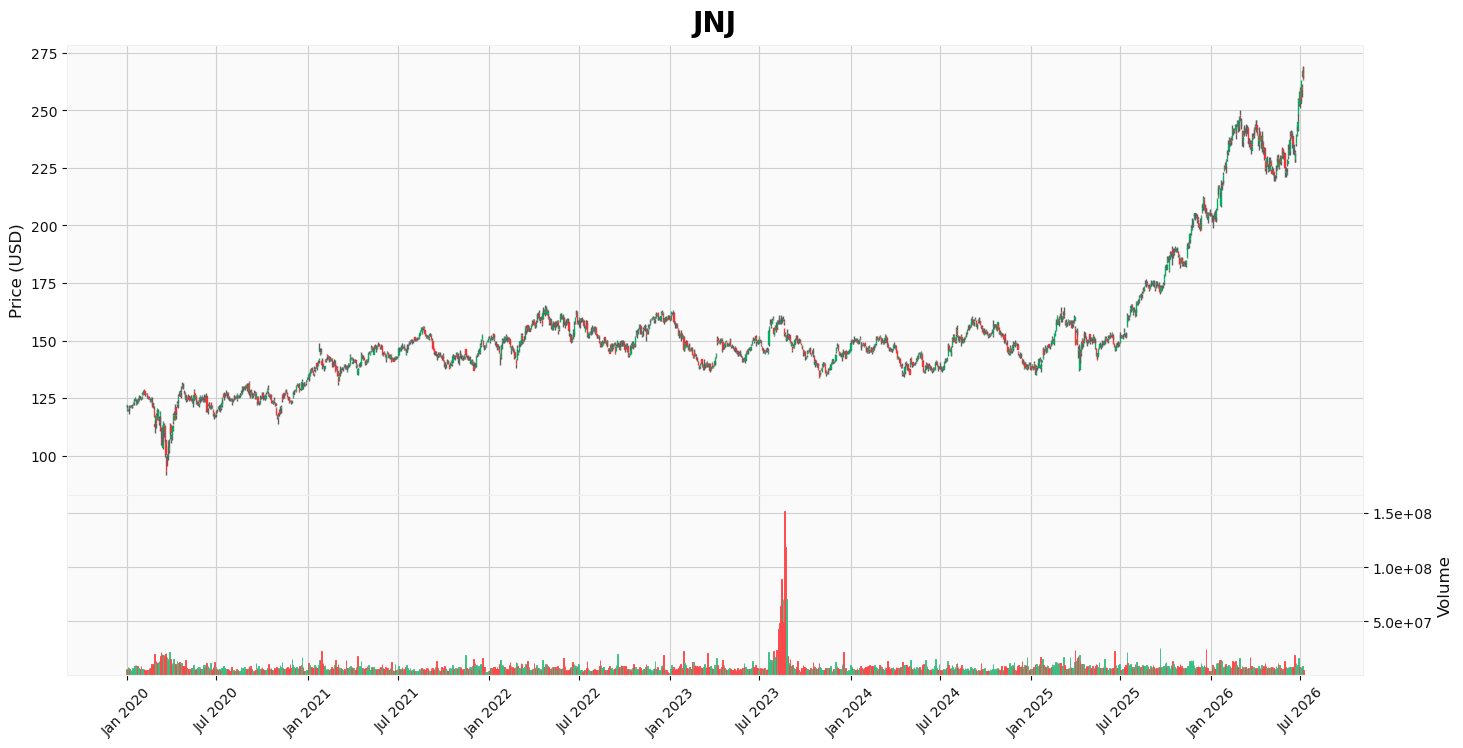

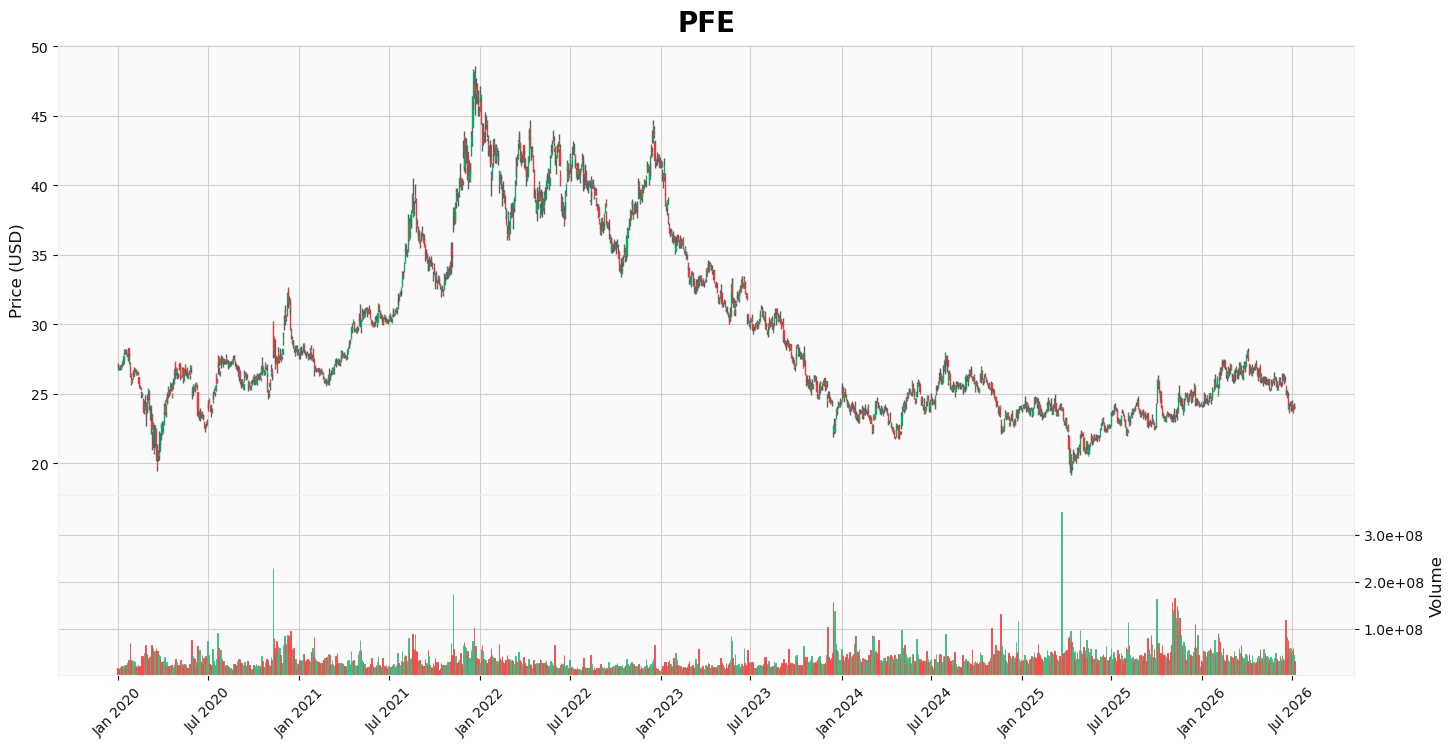

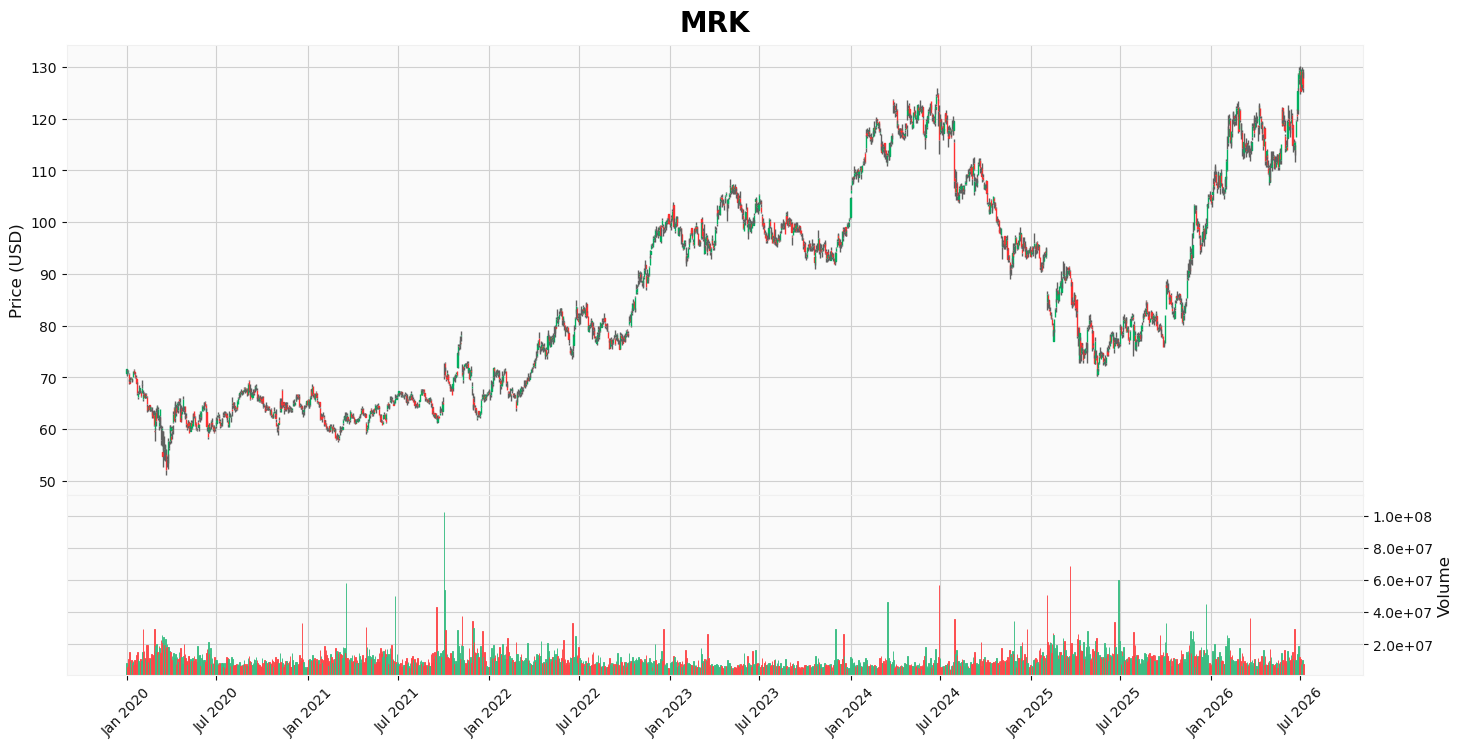

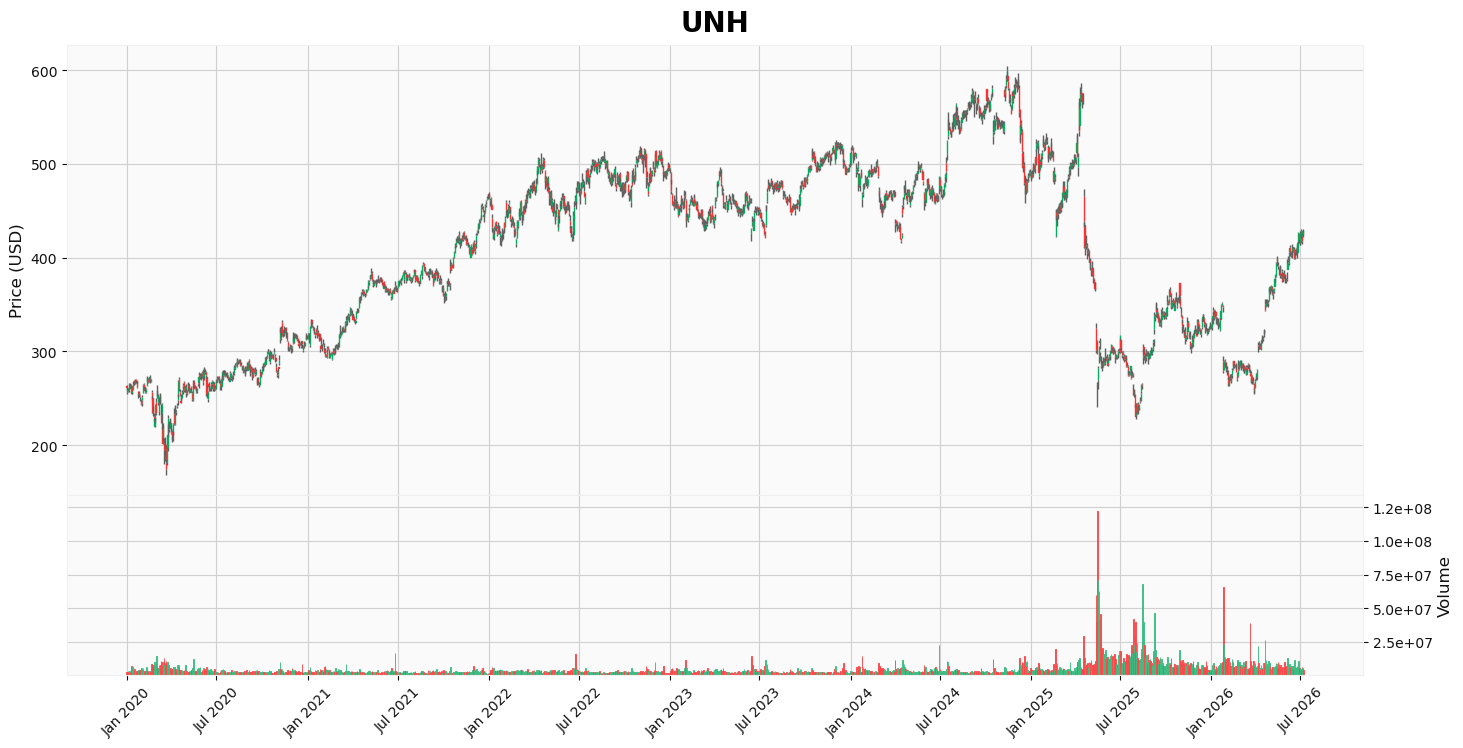

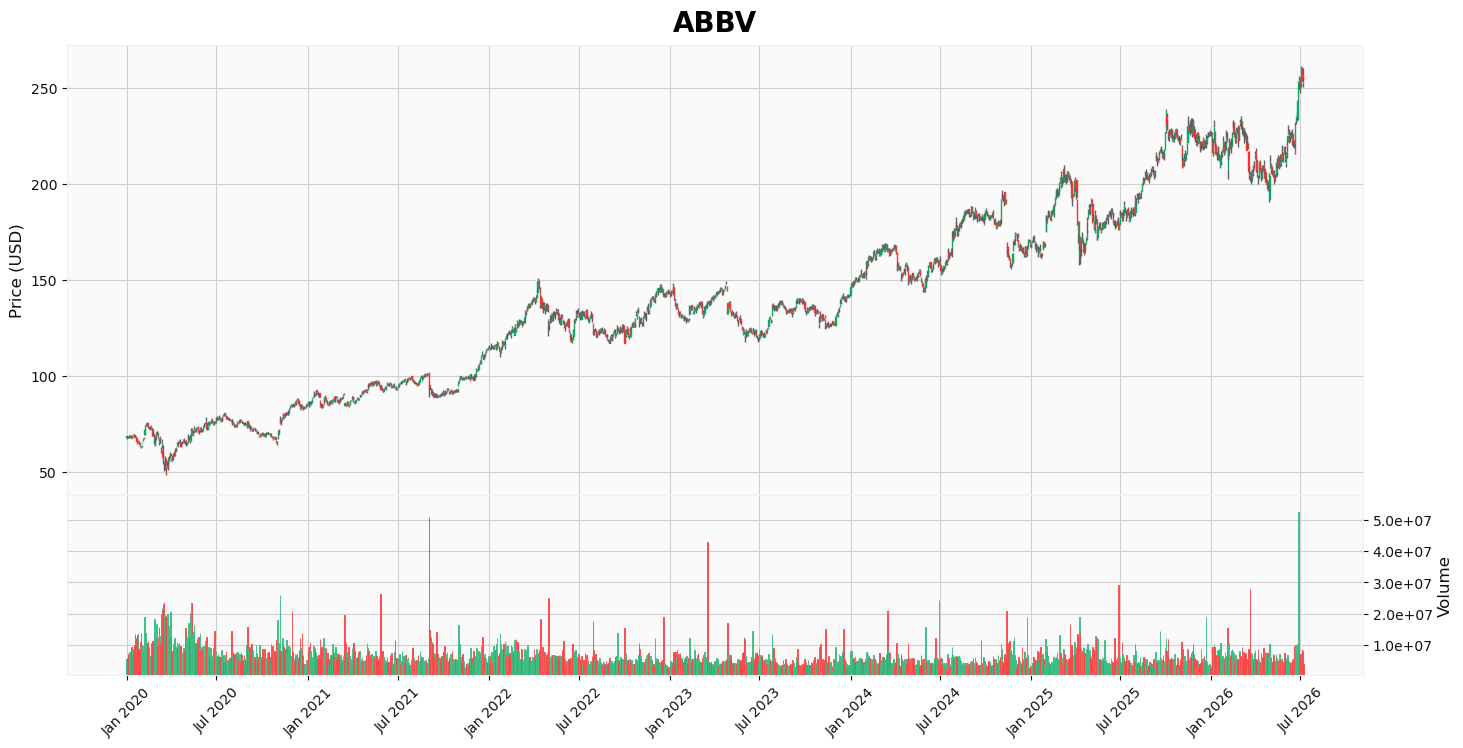

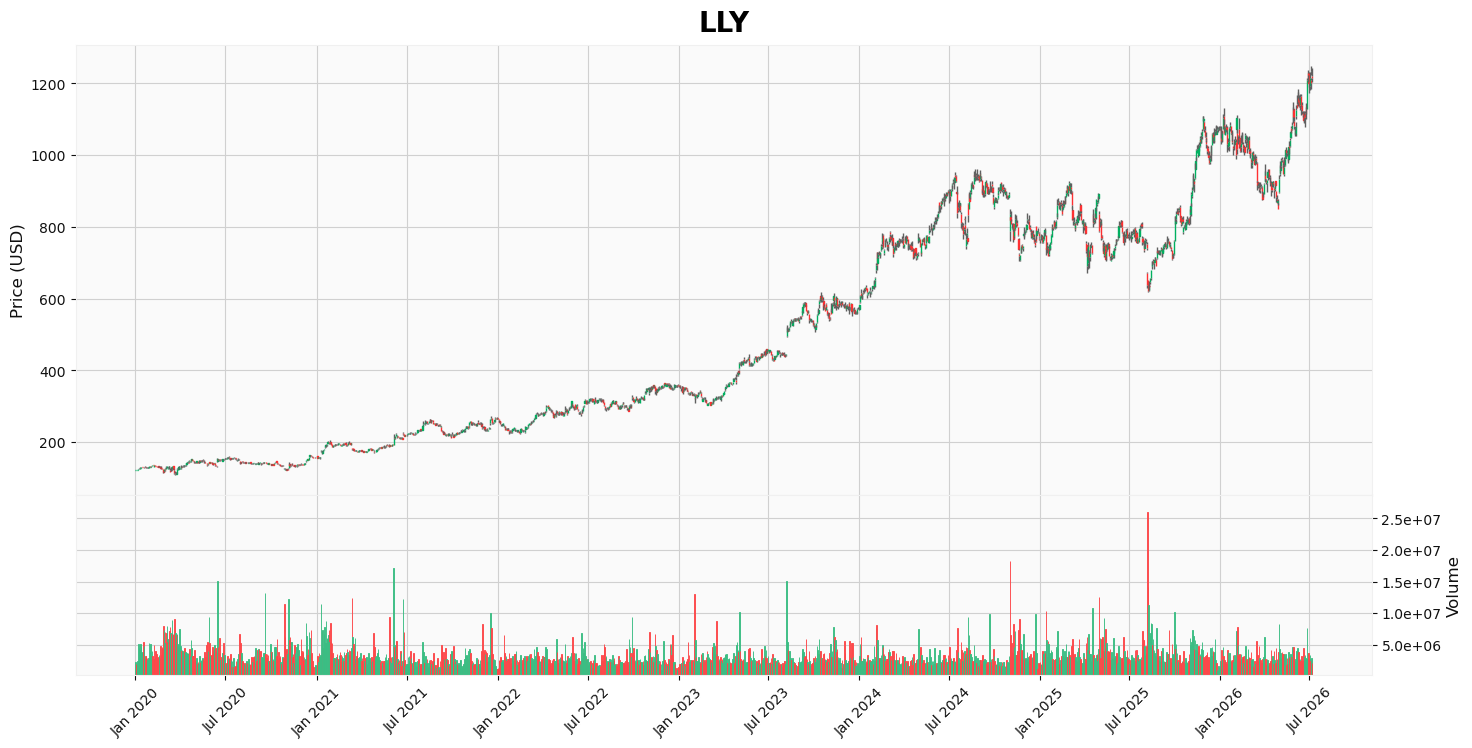

In [7]:
healthcare_companies = ["JNJ", "PFE", "MRK", "UNH", "ABBV", "LLY"]

for comp in healthcare_companies:
    plot_candlestick_with_volume(comp, data)

---
## <u>Modeling Setup</u>
- This section builds three stock forecasting pipelines using the same selected ticker, chronological train/test split, and one-step-ahead closing-price prediction task. 
- The LSTM model uses multivariate 30-day sequences, XGBoost uses engineered tabular features to predict next-day return, and N-BEATS uses only historical closing prices as a univariate sequence. 
- Each model is trained, evaluated with consistent performance metrics, and visualized against actual test-period prices.

---
##### **Company Selection**

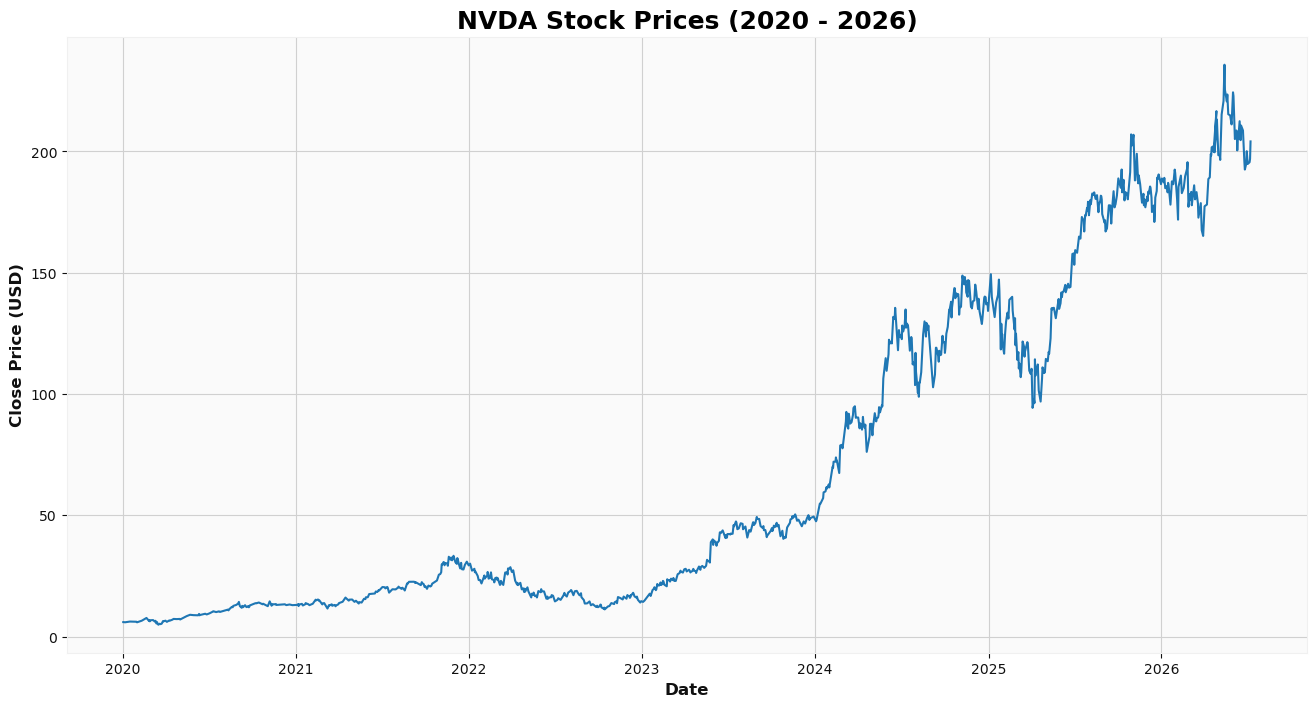

In [8]:
# Select a company for model predictions
# desired_company = input("Please enter the ticker for the company you want to generate predictions for: ")
desired_company = "NVDA" # change this ticker to test a different company

desired_company = desired_company.strip().upper()
prediction_data = data[data["Ticker"] == desired_company].copy()

if prediction_data.empty:
    raise ValueError(f"No data found for ticker: {desired_company}")

plt.figure(figsize = (16, 8))
plt.plot(prediction_data["Date"], prediction_data["Close"])

plt.xlabel("Date", fontsize = 12, fontweight = "bold")
plt.ylabel("Close Price (USD)", fontsize = 12, fontweight = "bold")
plt.title(f"{desired_company} Stock Prices ({start_year} - {end_year})", fontsize = 18, fontweight = "bold")

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show() # visualize historical performance of selected company

---
##### **Shared Train/Test Setup**

In [9]:
# This section establishes the same train/test split for all three model implementations.
# Each model predicts the closing price on day t+1 using information available through day t.

prediction_data = prediction_data.sort_values("Date").reset_index(drop=True)

price_data = prediction_data.filter(["Close"])
dataset = price_data.values.astype(float)

# Separate the first 95% of rows for training and the final 5% for testing
training_set = int(np.ceil(len(dataset) * 0.95))

# Data preparation for future plotting
close_values = dataset.flatten()
date_values = prediction_data["Date"].values

print(f"Selected ticker  : {desired_company}")
print(f"Total rows       : {len(prediction_data)}")
print(f"Training rows    : {training_set}")
print(f"Test rows        : {len(prediction_data) - training_set}")

Selected ticker  : NVDA
Total rows       : 1636
Training rows    : 1555
Test rows        : 81


---
## <u>LSTM Model</u>
An LSTM, or Long Short-Term Memory network, is a type of neural network designed for sequential data. It processes information in order and learns how past observations relate to future values. The model uses internal memory mechanisms to decide which information from earlier time steps should be retained, updated, or ignored. This makes it useful for time-series forecasting problems where the order of past data matters.

In this project, the LSTM is used to predict the stock’s next closing price based on the previous 30 trading days. Each 30-day sequence contains multiple features, including closing price, daily return, intraday range, volume change, distance from the 10-day moving average, and SPY daily return. The model learns patterns across these recent daily observations and produces a forecast for the next closing price.

---
##### **Feature Engineering & Window Preparation**

In [10]:
# The LSTM receives a 30-day sequence on which the model is trained, where each day contains the following features:
#   - Price Level
#   - Daily Return
#   - Daily Range
#   - Volume Change
#   - Short-term Trend
#   - S&P 500 Market Movement
LOOKBACK = 30

lstm_df = prediction_data[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()
lstm_df = lstm_df.sort_values("Date").reset_index(drop=True)
lstm_df["Original_Index"] = np.arange(len(lstm_df))

# Daily Return - how much the stock moved from yesterday to today
lstm_df["Return_1d"] = lstm_df["Close"].pct_change()

# Daily Range - captures volatility for each day 
lstm_df["High_Low_Range"] = (lstm_df["High"] - lstm_df["Low"]) / lstm_df["Close"]

# Volume Change - change in volume from previous day
lstm_df["Volume_Change"] = lstm_df["Volume"].pct_change()

# Short-term Trend - price position relative to 10-day moving average
lstm_df["SMA_10"] = lstm_df["Close"].rolling(10).mean()
lstm_df["Close_to_SMA_10"] = (lstm_df["Close"] / lstm_df["SMA_10"]) - 1

# S&P 500 Market Movement - reference for broad-market movement
spy_df = data[data["Ticker"] == "SPY"][["Date", "Close"]].copy() # using SPY to capture S&P 500 performance
spy_df = spy_df.sort_values("Date").reset_index(drop=True)
spy_df["SPY_Return_1d"] = spy_df["Close"].pct_change()
spy_df = spy_df[["Date", "SPY_Return_1d"]]

lstm_df = lstm_df.merge(spy_df, on="Date", how="left")

# Compact feature list for the LSTM sequence
sequence_feature_cols = ["Close", "Return_1d", "High_Low_Range", "Volume_Change", "Close_to_SMA_10", "SPY_Return_1d"]

# Drop rows with missing values from rolling/pct_change features.
lstm_required_cols = sequence_feature_cols + ["Date", "Close", "Original_Index"]
lstm_df = lstm_df.replace([np.inf, -np.inf], np.nan).dropna(subset=lstm_required_cols).copy()
lstm_df = lstm_df.reset_index(drop=True)

# Scale input features using only rows in training period
feature_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler.fit(lstm_df.loc[lstm_df["Original_Index"] < training_set, sequence_feature_cols])
lstm_features_scaled = feature_scaler.transform(lstm_df[sequence_feature_cols])

# Scale close price using only training prices
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(dataset[:training_set])
lstm_target_scaled = scaler.transform(lstm_df[["Close"]]).flatten()

x_train, y_train = [], []
x_test, y_test, lstm_test_dates = [], [], []
lstm_target_indices = []

# Build a sequence for each predicted day, where the input is the previous LOOKBACK trading days
for pos in range(LOOKBACK, len(lstm_df)):
    target_original_idx = int(lstm_df.loc[pos, "Original_Index"])
    window_original_indices = lstm_df.loc[pos - LOOKBACK: pos - 1, "Original_Index"].values

    # Ensure the model uses exactly the previous LOOKBACK trading rows.
    if len(window_original_indices) != LOOKBACK:
        continue
    if not np.all(np.diff(window_original_indices) == 1):
        continue
    if window_original_indices[-1] != target_original_idx - 1:
        continue

    x_window = lstm_features_scaled[pos - LOOKBACK: pos, :] # shaped as LOOKBACK days x 6 features
    y_value = lstm_target_scaled[pos] # target is the scaled closing price on the next day

    # Differentiate between training or testing data based on the target day
    if target_original_idx < training_set:
        x_train.append(x_window)
        y_train.append(y_value)
    else:
        x_test.append(x_window)
        y_test.append(lstm_df.loc[pos, "Close"])
        lstm_test_dates.append(lstm_df.loc[pos, "Date"])
        lstm_target_indices.append(target_original_idx)

# Store results as NumPy arrays to support Keras training
x_train = np.array(x_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)
y_test = np.array(y_test, dtype=float).reshape(-1, 1)
lstm_test_dates = np.array(lstm_test_dates)
lstm_target_indices = np.array(lstm_target_indices)

print(f"LSTM training samples : {x_train.shape[0]}")
print(f"LSTM test samples     : {x_test.shape[0]}")
print(f"Look-back window      : {LOOKBACK} days")
print(f"Features per day      : {x_train.shape[2]}")

LSTM training samples : 1516
LSTM test samples     : 81
Look-back window      : 30 days
Features per day      : 6


---
##### **Model Definition**

In [11]:
tf.random.set_seed(42) # support reproducibility

# Define the LSTM model
model = keras.models.Sequential([
    # Set input shape as LOOKBACK trading days x number of features per day
    keras.layers.Input(shape=(x_train.shape[1], x_train.shape[2])),

    # Reads the sequence and summarizes the pattern into 64 learned values
    keras.layers.LSTM(units=64),

    # Randomly overlooks 20% of units during training to avoid overfitting
    keras.layers.Dropout(0.20),

    # Dense layer lets the model learn nonlinear patterns before generating one output, the predicted closing price
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

---
##### **Training**

In [12]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mean_squared_error",)

# Prevents overtraining if validation loss stops improving
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=6,restore_best_weights=True)

# Train the LSTM model on the sequence
history = model.fit(x_train,y_train, epochs=40, batch_size=32, validation_split=0.10, shuffle=False, callbacks=[early_stop], verbose=1)

Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0183 - val_loss: 0.0194
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0510 - val_loss: 0.0013
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0810 - val_loss: 0.1015
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0259 - val_loss: 0.0310
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0065 - val_loss: 0.0072
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019 - val_loss: 0.0024
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 9/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018 - val_loss: 0.0030
Epoch 10/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - val_loss: 0.0046
Epoch 11/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0013 - val_loss: 0.0041
Epoch 12/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

---
##### **Performance Metrics**

In [13]:
# Evaluate one day at a time using the actual previous LOOKBACK days.
# The model is not retrained during testing, and previous predictions are
# never reused as inputs for later predictions.
lstm_preds_scaled = model.predict(x_test, verbose=0)
predicts = scaler.inverse_transform(lstm_preds_scaled).reshape(-1, 1) # convert scaled predictions back to real dollar prices

mse = mean_squared_error(y_test, predicts)
rmse = np.sqrt(mse)
lstm_mae = np.mean(np.abs(predicts.flatten() - y_test.flatten()))
lstm_mape = np.mean(np.abs((predicts.flatten() - y_test.flatten()) / y_test.flatten())) * 100

lstm_current_close = prediction_data["Close"].values[lstm_target_indices - 1]
actual_direction = np.sign(y_test.flatten() - lstm_current_close)
predicted_direction = np.sign(predicts.flatten() - lstm_current_close)
lstm_directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"LSTM MSE : {mse:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {lstm_mae:.4f}")
print(f"LSTM MAPE: {lstm_mape:.2f}%")
print(f"LSTM Directional Accuracy: {lstm_directional_accuracy: .2f}%")

LSTM MSE : 55.4369
LSTM RMSE: 7.4456
LSTM MAE : 5.8446
LSTM MAPE: 2.90%
LSTM Directional Accuracy:  46.91%


---
##### **Visualization**

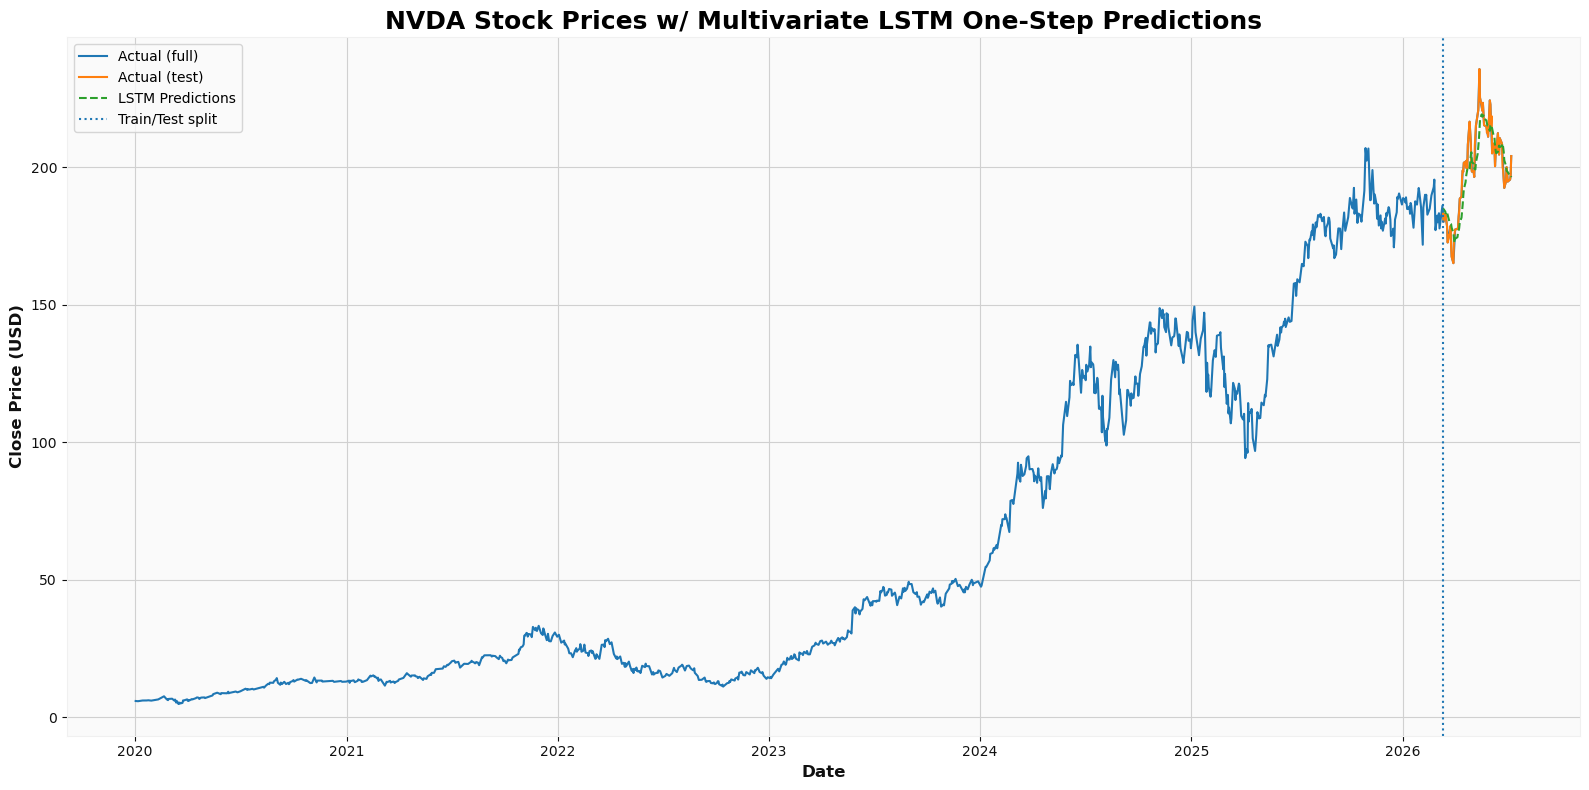

In [14]:
plt.figure(figsize=(16, 8))
plt.plot(prediction_data["Date"], prediction_data["Close"], label="Actual (full)")
plt.plot(lstm_test_dates, y_test.flatten(), label="Actual (test)")
plt.plot(lstm_test_dates, predicts.flatten(), label="LSTM Predictions", linestyle="--")

plt.axvline(x=prediction_data["Date"].values[training_set], linestyle=":", linewidth=1.5, label="Train/Test split")
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Close Price (USD)", fontsize=12, fontweight="bold")
plt.title(f"{desired_company} Stock Prices w/ Multivariate LSTM One-Step Predictions", fontsize=18, fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

---
## <u>XGBoost Model</u>

XGBoost is a machine learning model based on gradient-boosted decision trees. It builds many small decision trees one after another, where each new tree attempts to improve on the errors made by the previous trees. Instead of learning from raw sequences, XGBoost learns relationships from structured input features. It is especially effective when the data has many engineered variables that describe trends, patterns, and relationships.

In this project, XGBoost is used to predict the stock’s next-day return rather than the next closing price directly. The model is trained on engineered features such as lagged returns, moving-average relationships, volatility, momentum, RSI, MACD, volume-based features, calendar variables, and broader market returns from SPY and QQQ. After XGBoost predicts the next-day return, that return is converted into a predicted closing price so the model can be evaluated alongside the LSTM and N-BEATS forecasts.

---
##### **Feature Engineering**

In [15]:
xgb_df = prediction_data[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()
xgb_df = xgb_df.sort_values("Date").reset_index(drop=True)

# Basic daily movement features
xgb_df["Return_1d"] = xgb_df["Close"].pct_change()
xgb_df["Open_Close_Return"] = (xgb_df["Close"] - xgb_df["Open"]) / xgb_df["Open"]
xgb_df["High_Low_Range"] = (xgb_df["High"] - xgb_df["Low"]) / xgb_df["Close"]

# Store lagged returns to give XGBoost a tabular version of recent price history 
for lag in range(0, LOOKBACK):
    xgb_df[f"Return_lag_{lag}"] = xgb_df["Return_1d"].shift(lag)

# Rolling features summarize trend, volatility, and momentum across several windows
rolling_windows = [5, 10, 20, LOOKBACK]

for window in rolling_windows:
    xgb_df[f"SMA_{window}"] = xgb_df["Close"].rolling(window).mean()
    xgb_df[f"Close_to_SMA_{window}"] = (xgb_df["Close"] / xgb_df[f"SMA_{window}"]) - 1
    xgb_df[f"Volatility_{window}"] = xgb_df["Return_1d"].rolling(window).std()
    xgb_df[f"Momentum_{window}"] = xgb_df["Close"].pct_change(window)

# Volume features capture trading activity
xgb_df["Volume_Change"] = xgb_df["Volume"].pct_change()

for window in [5, 20]:
    xgb_df[f"Volume_SMA_{window}"] = xgb_df["Volume"].rolling(window).mean()
    xgb_df[f"Volume_to_SMA_{window}"] = xgb_df["Volume"] / xgb_df[f"Volume_SMA_{window}"]

# RSI - indicator of recent upward or downward trends
delta = xgb_df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
xgb_df["RSI_14"] = 100 - (100 / (1 + rs))

# Moving Average Convergence Divergence (MACD) features are technical indicators that try to capture trend and momentum by comparing a short-term moving average to a longer-term moving average
xgb_df["EMA_12"] = xgb_df["Close"].ewm(span=12, adjust=False).mean()
xgb_df["EMA_26"] = xgb_df["Close"].ewm(span=26, adjust=False).mean()
xgb_df["MACD"] = xgb_df["EMA_12"] - xgb_df["EMA_26"]
xgb_df["MACD_Signal"] = xgb_df["MACD"].ewm(span=9, adjust=False).mean()
xgb_df["MACD_Hist"] = xgb_df["MACD"] - xgb_df["MACD_Signal"]

# Calendar features
xgb_df["DayOfWeek"] = pd.to_datetime(xgb_df["Date"]).dt.dayofweek
xgb_df["Month"] = pd.to_datetime(xgb_df["Date"]).dt.month

# Market context: SPY and QQQ returns
market_df = data[data["Ticker"].isin(["SPY", "QQQ"])][["Date", "Ticker", "Close"]].copy()
market_df = market_df.pivot(index="Date", columns="Ticker", values="Close").reset_index()

market_df["SPY_Return_1d"] = market_df["SPY"].pct_change()
market_df["QQQ_Return_1d"] = market_df["QQQ"].pct_change()
market_df["SPY_Return_5d"] = market_df["SPY"].pct_change(5)
market_df["QQQ_Return_5d"] = market_df["QQQ"].pct_change(5)

market_features = ["Date", "SPY_Return_1d", "QQQ_Return_1d", "SPY_Return_5d", "QQQ_Return_5d"]

xgb_df = xgb_df.merge(market_df[market_features], on="Date", how="left")

xgb_df["Target_Close"] = xgb_df["Close"].shift(-1) #  stock closing price for the following day
xgb_df["Target_Return_1d"] = (xgb_df["Target_Close"] / xgb_df["Close"]) - 1 # stock percent return for the following day, which is what XGBoost learns to predict
xgb_df["Target_Date"] = xgb_df["Date"].shift(-1)
xgb_df["Target_Index"] = xgb_df.index + 1

xgb_df = xgb_df.replace([np.inf, -np.inf], np.nan).dropna().copy()

# Features to use
feature_cols = [
    "Close",
    "Open_Close_Return",
    "High_Low_Range",
    "Volume_Change",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "DayOfWeek",
    "Month",
    "SPY_Return_1d",
    "QQQ_Return_1d",
    "SPY_Return_5d",
    "QQQ_Return_5d",
]

# Add all lagged return features
feature_cols += [f"Return_lag_{lag}" for lag in range(0, LOOKBACK)]

# Add rolling features
for window in rolling_windows:
    feature_cols += [
        f"Close_to_SMA_{window}",
        f"Volatility_{window}",
        f"Momentum_{window}",
    ]

# Add volume-ratio features
feature_cols += ["Volume_to_SMA_5", "Volume_to_SMA_20"]

# Train/test split based on the target day, not the feature day
xgb_train_df = xgb_df[xgb_df["Target_Index"] < training_set].copy()
xgb_test_df = xgb_df[xgb_df["Target_Index"] >= training_set].copy()

# Build input matrix and target vector for XGBoost
X_train_xgb = xgb_train_df[feature_cols].values
y_train_xgb = xgb_train_df["Target_Return_1d"].values

X_test_xgb = xgb_test_df[feature_cols].values

print(f"XGBoost train samples : {X_train_xgb.shape[0]}")
print(f"XGBoost test samples  : {X_test_xgb.shape[0]}")
print(f"Features per sample   : {X_train_xgb.shape[1]}")
print(f"Look-back window      : {LOOKBACK} days")

XGBoost train samples : 1524
XGBoost test samples  : 81
Features per sample   : 58
Look-back window      : 30 days


---
##### **Model Definition & Training**

In [16]:
# Define the XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=800,               # number of boosted decision trees
    max_depth=3,                    # shallow trees reduce overfitting
    learning_rate=0.02,             # small learning rate makes update more gradual
    subsample=0.85,                 # each tree trains on 85% of rows
    colsample_bytree=0.85,          # each tree trains on 85% of features
    min_child_weight=5,             # discourages overly specific splits
    reg_alpha=0.1,                  # L1 regularization, which penalizes complex models
    reg_lambda=2.0,                 # L2 regularization, which discourages overreacting to patterns
    objective="reg:squarederror",   # identifies the problem the model is designed to solve, which is a regression task using squared error loss
    random_state=42,                # reproducibility
    n_jobs=-1,                      # number of CPU cores used
    verbosity=0,
)

xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=-1, num_parallel_tree=None, ...)

---
##### **Performance Metrics**

In [17]:
# XGBoost predicts the next-day return.
# Predicted next close = today's close * (1 + predicted return)

xgb_pred_returns = xgb_model.predict(X_test_xgb)

xgb_current_close = xgb_test_df["Close"].values
xgb_preds = xgb_current_close * (1 + xgb_pred_returns) # convert predicted return into predicted close

# Actual tomorrow close and dates for  testing
y_test_xgb_inv = xgb_test_df["Target_Close"].values
xgb_test_dates = xgb_test_df["Target_Date"].values

xgb_mse  = mean_squared_error(y_test_xgb_inv, xgb_preds)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae  = np.mean(np.abs(xgb_preds - y_test_xgb_inv))
xgb_mape = np.mean(np.abs((xgb_preds - y_test_xgb_inv) / y_test_xgb_inv)) * 100

actual_direction = np.sign(y_test_xgb_inv - xgb_current_close)
predicted_direction = np.sign(xgb_preds - xgb_current_close)
xgb_directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"XGBoost MSE : {xgb_mse:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE : {xgb_mae:.4f}")
print(f"XGBoost MAPE: {xgb_mape:.2f}%")
print(f"XGBoost Directional Accuracy: {xgb_directional_accuracy: .2f}%")

XGBoost MSE : 22.7390
XGBoost RMSE: 4.7685
XGBoost MAE : 3.7322
XGBoost MAPE: 1.85%
XGBoost Directional Accuracy:  55.56%


---
##### **Visualization**

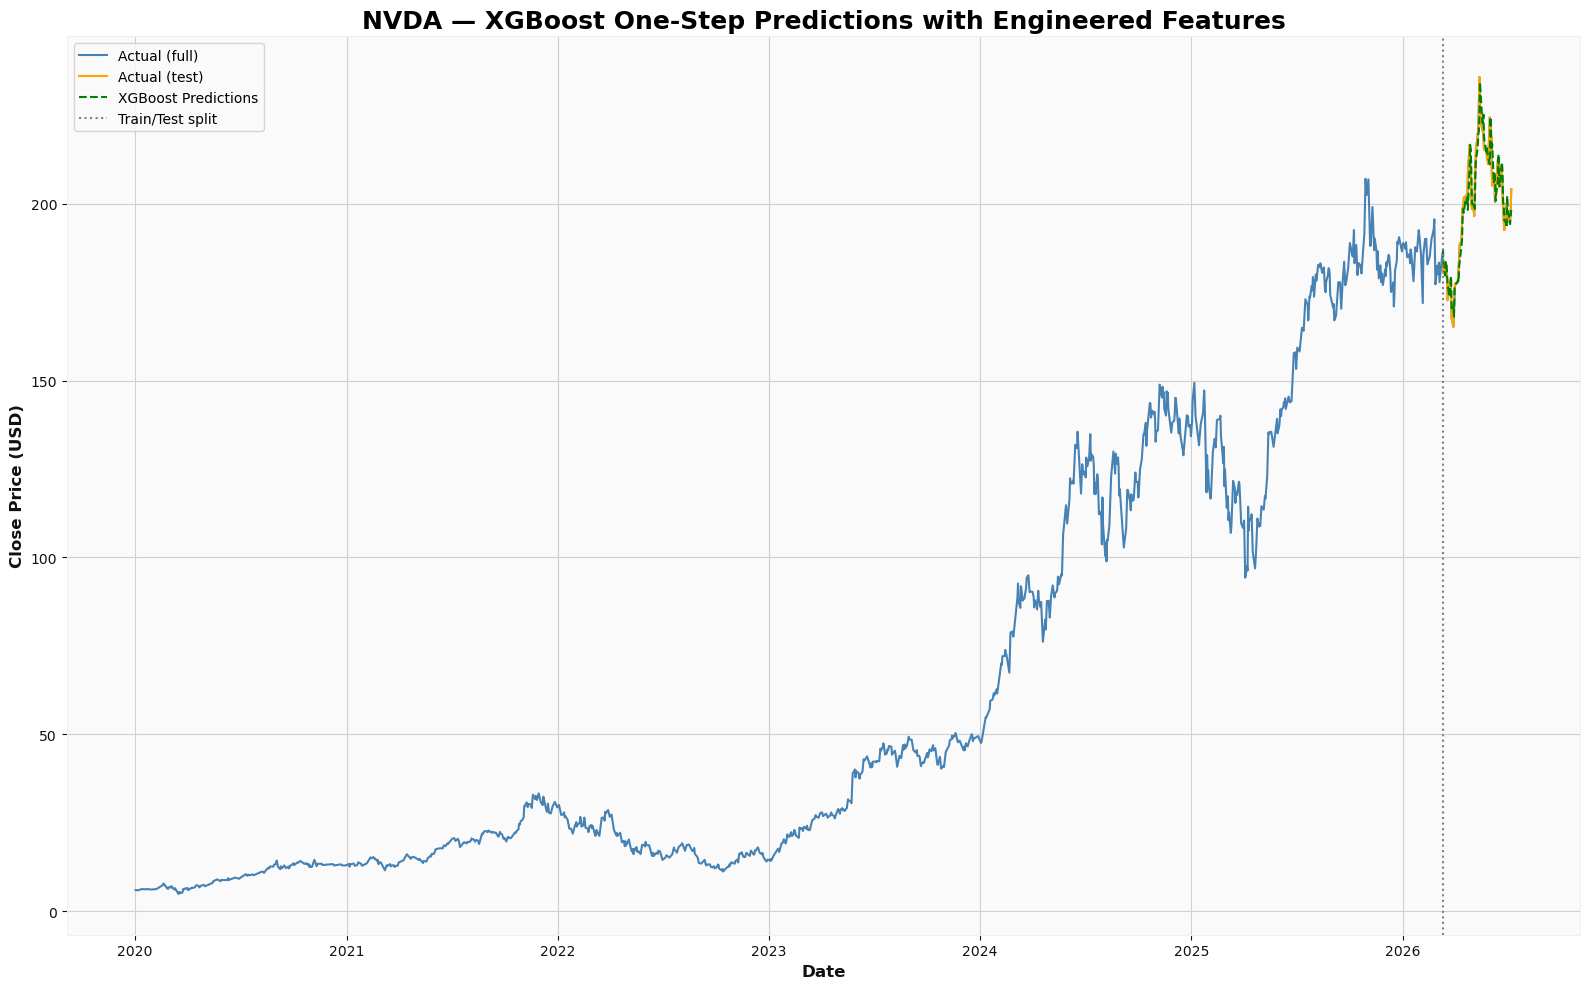

In [18]:
xgb_train_end = prediction_data["Date"].values[training_set]

plt.figure(figsize=(16, 10))
plt.plot(prediction_data["Date"], prediction_data["Close"], label="Actual (full)", color="steelblue")
plt.plot(xgb_test_dates, y_test_xgb_inv, label="Actual (test)", color="orange")
plt.plot(xgb_test_dates, xgb_preds, label="XGBoost Predictions", color="green", linestyle="--")

plt.axvline(x=xgb_train_end, color="grey", linestyle=":", linewidth=1.5, label="Train/Test split")
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Close Price (USD)", fontsize=12, fontweight="bold")
plt.title(f"{desired_company} — XGBoost One-Step Predictions with Engineered Features", fontsize=18, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

---
##### **Feature Importance**

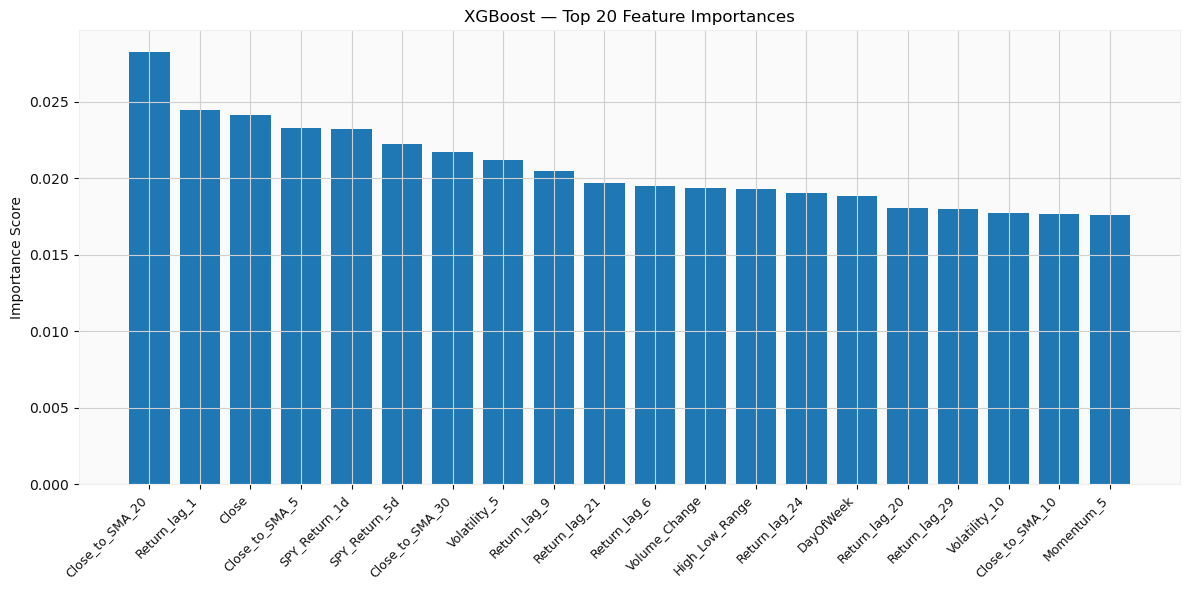

In [19]:
importances = xgb_model.feature_importances_

top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(top_n), importances[top_idx])
plt.xticks(range(top_n), [feature_cols[i] for i in top_idx], rotation=45, ha="right", fontsize=9)
plt.ylabel("Importance Score")
plt.title("XGBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.show()

---
## <u>N-BEATS Model</u>

N-BEATS is a neural network architecture designed specifically for time-series forecasting. It uses fully connected layers arranged in blocks that learn patterns from historical values and generate a forecast. Rather than using recurrence, the model learns from fixed windows of past observations and updates its internal weights during training to reduce forecasting error. Its structure allows it to model time-series behavior directly from historical data.

In this project, N-BEATS is used as a univariate forecasting model, meaning it only uses the stock’s historical closing prices as input. The model receives the previous 30 trading days of closing prices and predicts the next closing price. This allows the project to test how well a sequence-based neural forecasting model performs using only the stock’s own price history, without additional technical indicators or market-context features.

---
##### **Data Preparation**

In [20]:
# N-BEATS is used as a univariate sequence model that only receives historical closing prices as input.

# Scale close prices using only the training set to avoid leakage.
nbeats_scaler = MinMaxScaler(feature_range=(0, 1))
nbeats_scaler.fit(dataset[:training_set].reshape(-1, 1))
nbeats_scaled = nbeats_scaler.transform(dataset.reshape(-1, 1)).flatten()

def build_sequence_windows(series, first_target_idx, last_target_exclusive, lookback=LOOKBACK):
    """Build sequence windows where each target is the next day after the window.

    Each X window contains the prior lookback values.
    Each y target is the next value immediately after that window.
    """
    x, y = [], []
    for i in range(first_target_idx, last_target_exclusive):
        x.append(series[i - lookback: i])
        y.append(series[i])
    return np.array(x, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

# Training windows predict training-period target days
x_train_nbeats, y_train_nbeats = build_sequence_windows(
    nbeats_scaled,
    first_target_idx=LOOKBACK,
    last_target_exclusive=training_set,
)

# Test windows use real prior prices to predict test days
X_test_nbeats, y_test_nbeats_scaled = build_sequence_windows(
    nbeats_scaled,
    first_target_idx=training_set,
    last_target_exclusive=len(nbeats_scaled),
)

print(f"N-BEATS train samples: {x_train_nbeats.shape[0]}")
print(f"N-BEATS test samples : {X_test_nbeats.shape[0]}")
print(f"Look-back window     : {LOOKBACK} days")

N-BEATS train samples: 1525
N-BEATS test samples : 81
Look-back window     : 30 days


---
##### **Model Definition & Training**

In [21]:
torch.manual_seed(42)
torch.set_num_threads(1)  # reduces CPU overhead for this small training loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # use GPU if available, otherwise use CPU

# Convert NumPy arrays into PyTorch tensors, which is PyTorch's version of an array used for neural network training
train_ds = TensorDataset(
    torch.tensor(x_train_nbeats, dtype=torch.float32),
    torch.tensor(y_train_nbeats, dtype=torch.float32),
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Define the N-BEATS model
nbeats_model = NBeatsNet(
    device=device,                  # selects hardware to run model     
    stack_types=(                   # assign each stack a general block to learn patterns from closing prices
        NBeatsNet.GENERIC_BLOCK, 
        NBeatsNet.GENERIC_BLOCK
        ),                          
    nb_blocks_per_stack=2,          # assign 2 blocks per stack
    forecast_length=1,              # one-step-ahead forecast
    backcast_length=LOOKBACK,       # 30 real prior days
    thetas_dim=(8, 8),              # learning capacity
    share_weights_in_stack=False,   # each block holds its own weights
    hidden_layer_units=64,
).to(device)

# Adam updates the model weights
optimizer = torch.optim.Adam(nbeats_model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()
NBEATS_EPOCHS = 50

nbeats_model.train()
for epoch in range(1, NBEATS_EPOCHS + 1):
    epoch_losses = []
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        _, forecast = nbeats_model(batch_x)
        loss = loss_fn(forecast, batch_y)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    if epoch == 1 or epoch % 10 == 0 or epoch == NBEATS_EPOCHS:
        print(f"Epoch {epoch:03d}/{NBEATS_EPOCHS} - loss: {np.mean(epoch_losses):.6f}")


| N-Beats
| --  Stack Generic (#0) (share_weights_in_stack=False)
     | -- GenericBlock(units=64, thetas_dim=8, backcast_length=30, forecast_length=1, share_thetas=False) at @2713358066624
     | -- GenericBlock(units=64, thetas_dim=8, backcast_length=30, forecast_length=1, share_thetas=False) at @2713433481104
| --  Stack Generic (#1) (share_weights_in_stack=False)
     | -- GenericBlock(units=64, thetas_dim=8, backcast_length=30, forecast_length=1, share_thetas=False) at @2713433481424
     | -- GenericBlock(units=64, thetas_dim=8, backcast_length=30, forecast_length=1, share_thetas=False) at @2713329108848
Epoch 001/50 - loss: 0.058098
Epoch 010/50 - loss: 0.000532
Epoch 020/50 - loss: 0.000357
Epoch 030/50 - loss: 0.000339
Epoch 040/50 - loss: 0.000355
Epoch 050/50 - loss: 0.000253


---
##### **Performance Metrics**

In [22]:
nbeats_model.eval() # evaluation mode for model

# Generate predictions without tracking gradients
with torch.no_grad():
    test_tensor = torch.tensor(X_test_nbeats, dtype=torch.float32).to(device)
    _, nbeats_preds_scaled_tensor = nbeats_model(test_tensor)

# Convert PyTorch tensor outputs back into NumPy
nbeats_preds_scaled = nbeats_preds_scaled_tensor.cpu().numpy()

# Convert scaled predictions back into dollar closing prices
nbeats_preds = nbeats_scaler.inverse_transform(nbeats_preds_scaled).flatten()

nbeats_actual = prediction_data["Close"].values[training_set:]

nbeats_mse  = mean_squared_error(nbeats_actual, nbeats_preds)
nbeats_rmse = np.sqrt(nbeats_mse)
nbeats_mae  = np.mean(np.abs(nbeats_preds - nbeats_actual))
nbeats_mape = np.mean(np.abs((nbeats_preds - nbeats_actual) / nbeats_actual)) * 100

nbeats_current_close = prediction_data["Close"].values[training_set - 1 : len(prediction_data) - 1]
actual_direction = np.sign(nbeats_actual - nbeats_current_close)
predicted_direction = np.sign(nbeats_preds - nbeats_current_close)
nbeats_directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print(f"N-BEATS MSE : {nbeats_mse:.4f}")
print(f"N-BEATS RMSE: {nbeats_rmse:.4f}")
print(f"N-BEATS MAE : {nbeats_mae:.4f}")
print(f"N-BEATS MAPE: {nbeats_mape:.2f}%")
print(f"N-BEATS Directional Accuracy: {nbeats_directional_accuracy: .2f}%")

N-BEATS MSE : 54.0004
N-BEATS RMSE: 7.3485
N-BEATS MAE : 5.8222
N-BEATS MAPE: 2.88%
N-BEATS Directional Accuracy:  46.91%


---
##### **Visualization**

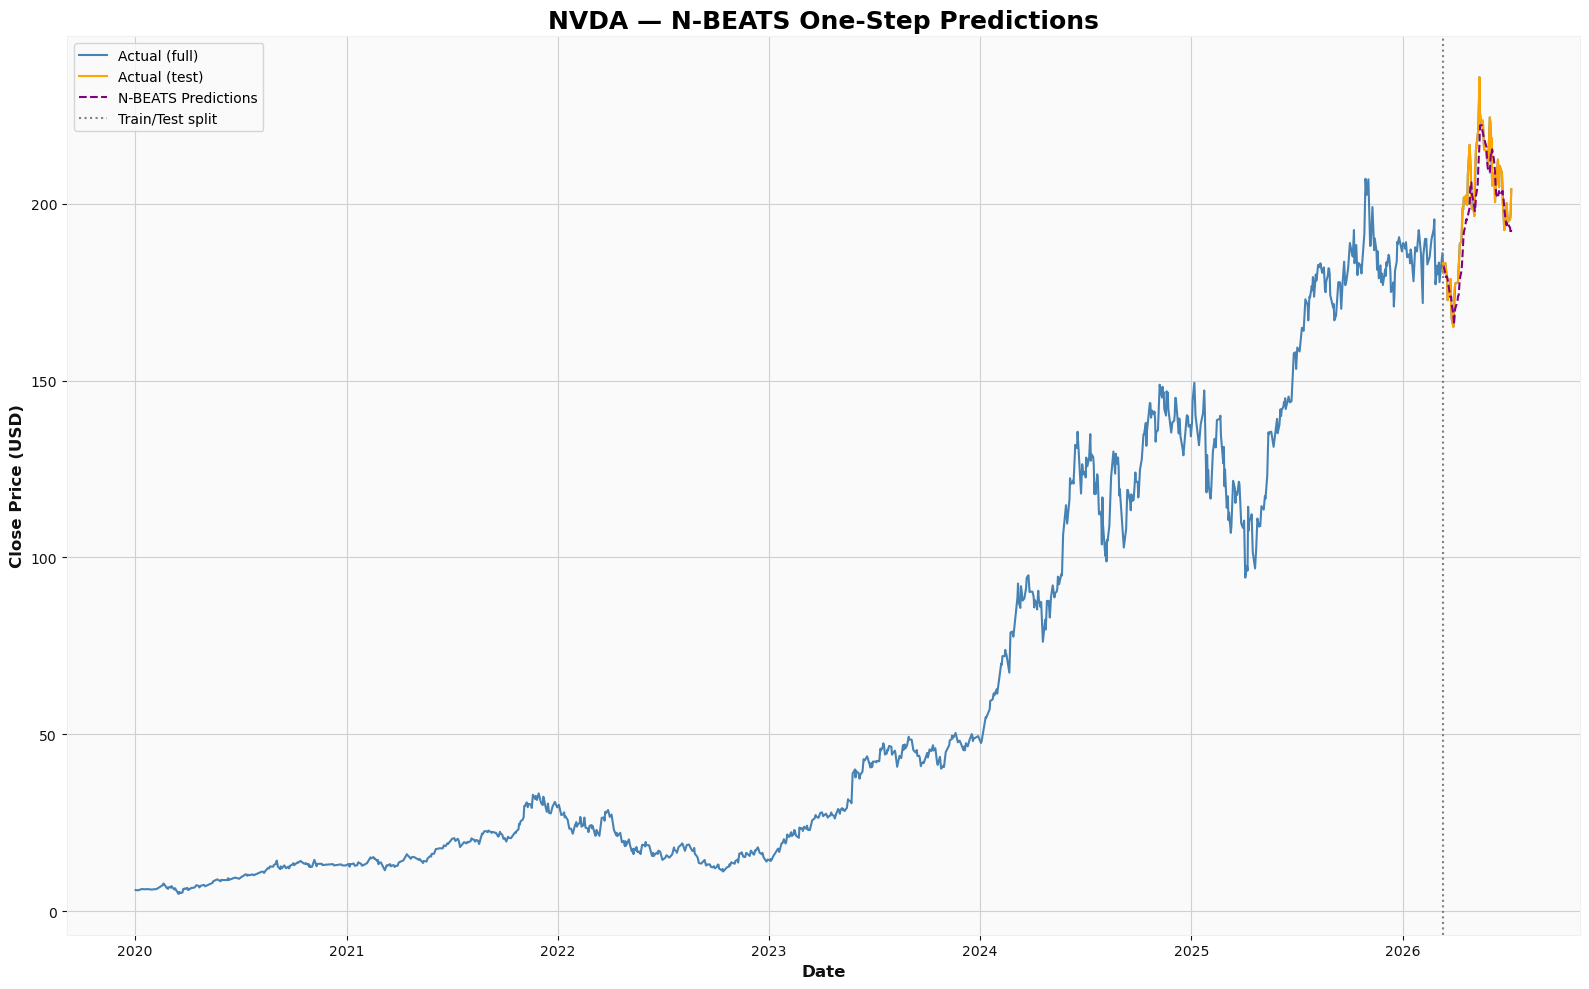

In [23]:
nbeats_test_dates = prediction_data["Date"].values[training_set:]

plt.figure(figsize=(16, 10))
plt.plot(prediction_data["Date"], prediction_data["Close"], label="Actual (full)", color="steelblue")
plt.plot(nbeats_test_dates, nbeats_actual, label="Actual (test)", color="orange")
plt.plot(nbeats_test_dates, nbeats_preds, label="N-BEATS Predictions", color="purple", linestyle="--")

plt.axvline(x=nbeats_test_dates[0], color="grey", linestyle=":", linewidth=1.5, label="Train/Test split")
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Close Price (USD)", fontsize=12, fontweight="bold")
plt.title(f"{desired_company} — N-BEATS One-Step Predictions", fontsize=18, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


---
## <u>Model Comparison</u>

The final comparison evaluates each model as a forecasting pipeline for the same one-step-ahead closing price prediction task:

- **LSTM:** multivariate 30-day sequence of engineered daily features.
- **XGBoost:** engineered tabular features.
- **N-BEATS:** univariate close-price sequence.

---
##### **Metrics Table**

In [24]:
# All three models use the same one-step-ahead protocol and the same train/test split.
comparison = pd.DataFrame({
    "Model" : ["LSTM",    "XGBoost",  "N-BEATS"],
    "Input Strategy": [
        "Multivariate sequence",
        "Engineered tabular features",
        "Univariate sequence",
    ],
    "RMSE"  : [rmse,      xgb_rmse,   nbeats_rmse],
    "MAE"   : [lstm_mae,  xgb_mae,    nbeats_mae],
    "MAPE%" : [lstm_mape, xgb_mape,   nbeats_mape],
    "Directional Accuracy%": [lstm_directional_accuracy, xgb_directional_accuracy, nbeats_directional_accuracy]
})
comparison = comparison.set_index("Model")
print(comparison.round(4).to_string())

                      Input Strategy    RMSE     MAE   MAPE%  Directional Accuracy%
Model                                                                              
LSTM           Multivariate sequence  7.4456  5.8446  2.8994                46.9136
XGBoost  Engineered tabular features  4.7685  3.7322  1.8483                55.5556
N-BEATS          Univariate sequence  7.3485  5.8222  2.8764                46.9136


---
##### **Model Performance Comparison**

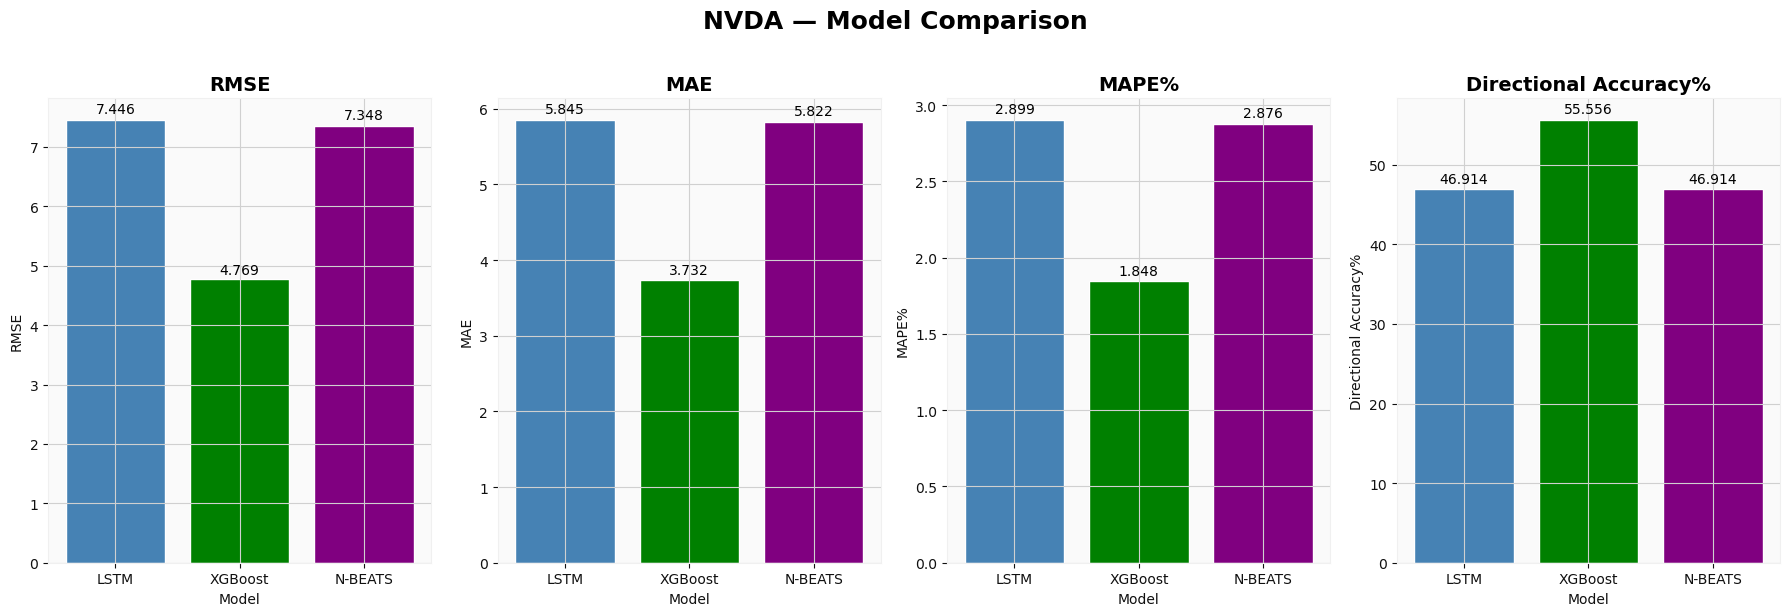

In [25]:
# Compare performance metrics for each model
metrics = ["RMSE", "MAE", "MAPE%", "Directional Accuracy%"]
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

colors = ["steelblue", "green", "purple"]
for ax, metric in zip(axes, metrics):
    bars = ax.bar(comparison.index, comparison[metric], color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=10,
        )

plt.suptitle(f"{desired_company} — Model Comparison", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
##### **Predicted Prices Comparison**

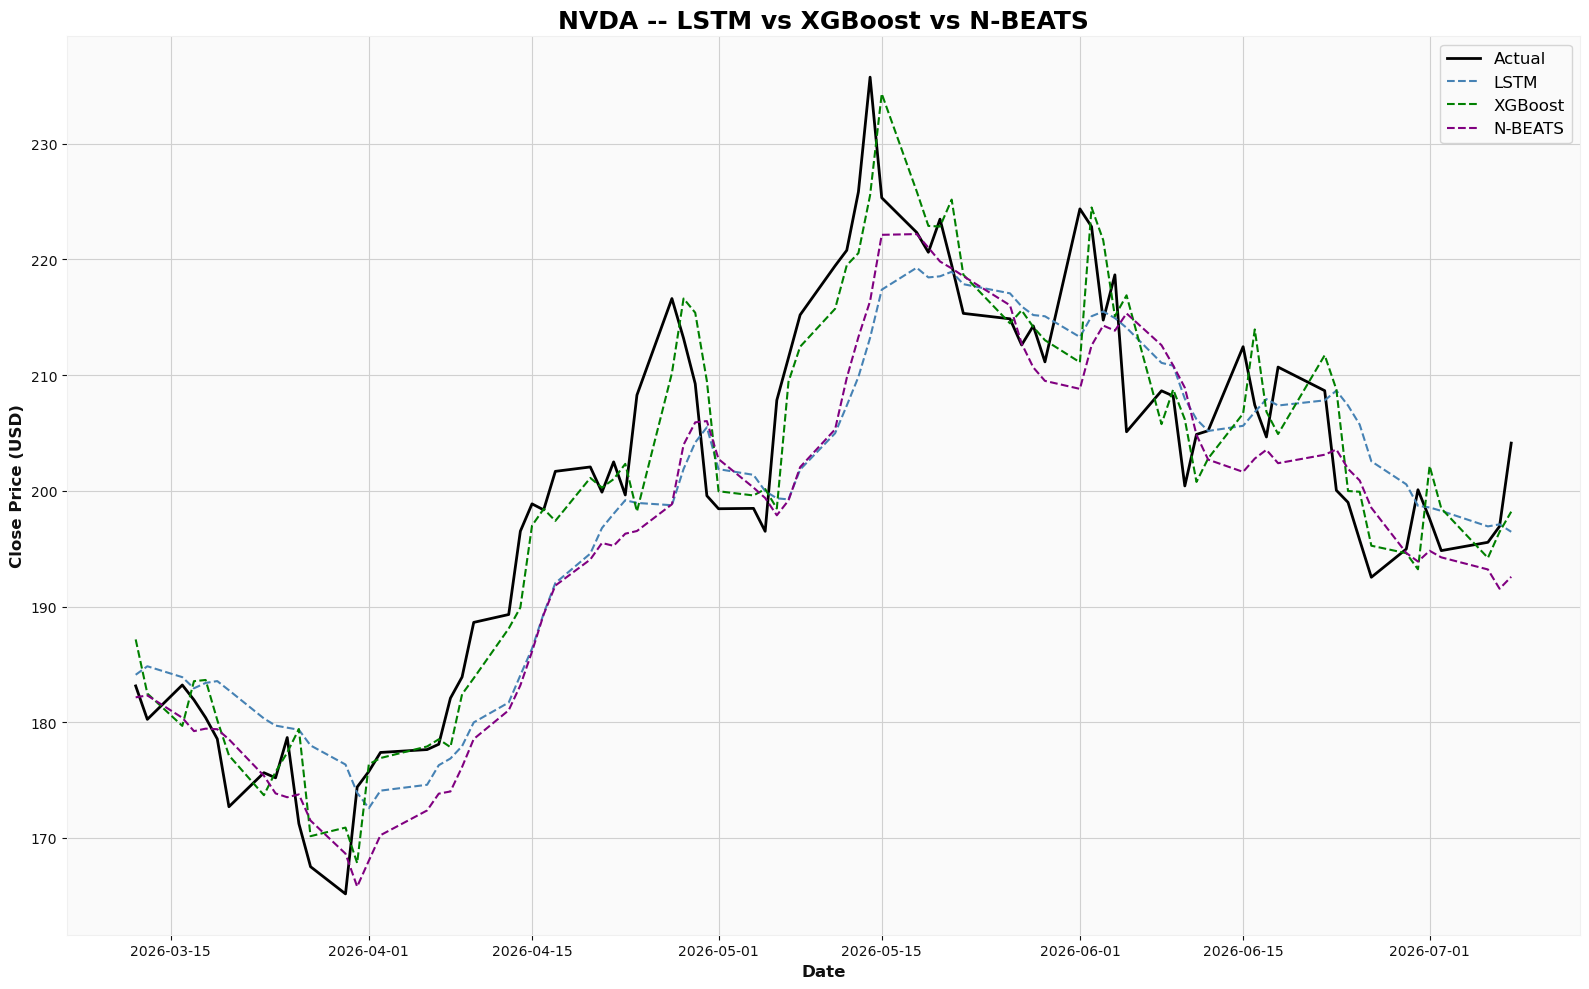

In [26]:
# Visualize closing price predictions for each model against the actual closing prices during the testing period
plt.figure(figsize=(16, 10))

plt.plot(lstm_test_dates, y_test.flatten(), label="Actual", color="black", linewidth=2)
plt.plot(lstm_test_dates, predicts.flatten(), label="LSTM", color="steelblue", linestyle="--")
plt.plot(xgb_test_dates, xgb_preds, label="XGBoost", color="green", linestyle="--")
plt.plot(nbeats_test_dates, nbeats_preds, label="N-BEATS", color="purple", linestyle="--")

plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Close Price (USD)", fontsize=12, fontweight="bold")
plt.title(f"{desired_company} -- LSTM vs XGBoost vs N-BEATS", fontsize=18, fontweight="bold")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()